In [1]:
# The Base libraries
import numpy as np
import matplotlib.pyplot as plt
import laspy
import cv2
import time
# The Deep Learning libraries
import torch
from segment_anything import sam_model_registry
from segment_anything import SamAutomaticMaskGenerator

In [3]:
print(torch.cuda.is_available())

True


In [4]:
MODEL = "MODELS/sam_vit_h_4b8939.pth"
USED_D = torch.device('cuda:0')
sam = sam_model_registry["vit_h"](checkpoint = MODEL)
sam.to(device = USED_D)


Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 1280, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-31): 32 x Block(
        (norm1): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=1280, out_features=3840, bias=True)
          (proj): Linear(in_features=1280, out_features=1280, bias=True)
        )
        (norm2): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=1280, out_features=5120, bias=True)
          (lin2): Linear(in_features=5120, out_features=1280, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(1280, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d

In [5]:
mask_generator = SamAutomaticMaskGenerator(sam)
result = mask_generator.generate(image_rgb)


NameError: name 'image_rgb' is not defined

In [2]:
def sam_masks(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)
    c_mask=[]
    for ann in sorted_anns:
        m = ann['segmentation']
        img = np.ones((m.shape[0], m.shape[1], 3))
        color_mask = np.random.random((1, 3)).tolist()[0]
        for i in range(3):
            img[:,:,i] = color_mask[i]
        ax.imshow(np.dstack((img, m*0.8)))
        c_mask.append(img)
    return c_mask

def cloud_to_image(pcd_np, resolution):
    minx = np.min(pcd_np[:, 0])
    maxx = np.max(pcd_np[:, 0])
    miny = np.min(pcd_np[:, 1])
    maxy = np.max(pcd_np[:, 1])
    width = int((maxx - minx) / resolution) + 1
    height = int((maxy - miny) / resolution) + 1
    image = np.zeros((height, width, 3), dtype=np.uint8)
    for point in pcd_np:
        x, y, *_ = point
        r, g, b = point[-3:]
        pixel_x = int((x - minx) / resolution)
        pixel_y = int((maxy - y) / resolution)
        image[pixel_y, pixel_x] = [r, g, b]
    return image

def generate_spherical_image(center_coordinates, point_cloud, colors, resolution_y=500):
    # Translate the point cloud by the negation of the center coordinates
    translated_points = point_cloud - center_coordinates

    # Convert 3D point cloud to spherical coordinates
    theta = np.arctan2(translated_points[:, 1], translated_points[:, 0])
    phi = np.arccos(translated_points[:, 2] / np.linalg.norm(translated_points, axis=1))

    # Map spherical coordinates to pixel coordinates
    x = (theta + np.pi) / (2 * np.pi) * (2 * resolution_y)
    y = phi / np.pi * resolution_y

     # Create the spherical image with RGB channels
    resolution_x = 2 * resolution_y
    image = np.zeros((resolution_y, resolution_x, 3), dtype=np.uint8)

    # Create the mapping between point cloud and image coordinates
    mapping = np.full((resolution_y, resolution_x), -1, dtype=int)

    # Assign points to the image pixels
    for i in range(len(translated_points)):
        ix = np.clip(int(x[i]), 0, resolution_x - 1)
        iy = np.clip(int(y[i]), 0, resolution_y - 1)
        if mapping[iy, ix] == -1 or np.linalg.norm(translated_points[i]) < np.linalg.norm(translated_points[mapping[iy, ix]]):
            mapping[iy, ix] = i
            image[iy, ix] = colors[i]
    return image, mapping

def generate_spherical_image_fast(center_coordinates, point_cloud, colors, resolution_y=500):
    """
    Vectorized spherical projection that picks the closest point per pixel.
    Returns (image, mapping) where mapping[y,x] is the point index or -1.
    """
    # Ensure numpy arrays
    pts = np.asarray(point_cloud, dtype=np.float32)
    colors = np.asarray(colors, dtype=np.uint8)
    center = np.asarray(center_coordinates, dtype=np.float32)

    # Translate points
    translated = pts - center  # shape (N,3)
    x_p, y_p, z_p = translated[:, 0], translated[:, 1], translated[:, 2]

    # Distances (norms) for depth comparison
    # use hypot to compute sqrt(x^2+y^2+z^2) robustly
    dists = np.sqrt(x_p * x_p + y_p * y_p + z_p * z_p)  # shape (N,)

    # Avoid division by zero when computing phi: clamp dists > 0
    eps = 1e-12
    inv_d = 1.0 / np.maximum(dists, eps)

    # Spherical coordinates (theta in [-pi, pi], phi in [0, pi])
    theta = -np.arctan2(y_p, x_p)                  # [-pi, pi]
    # theta = np.mod(theta, 2 * np.pi)
    phi = np.arccos(np.clip(z_p * inv_d, -1.0, 1.0))  # [0, pi]

    # Map to pixel coordinates╚
    resolution_x = 2 * resolution_y
    ix = np.floor((theta + np.pi) / (2 * np.pi) * resolution_x).astype(np.int64)
    iy = np.floor(phi / np.pi * resolution_y).astype(np.int64)

    # Clip to image bounds (should be rare if math is correct)
    ix = np.clip(ix, 0, resolution_x - 1)
    iy = np.clip(iy, 0, resolution_y - 1)

    # Compute flat pixel indices
    flat_idx = iy * resolution_x + ix  # shape (N,)
    n_pixels = resolution_x * resolution_y

    # If no points, return empty image
    if pts.shape[0] == 0:
        image = np.zeros((resolution_y, resolution_x, 3), dtype=np.uint8)
        mapping = np.full((resolution_y, resolution_x), -1, dtype=np.int64)
        return image, mapping

    # Sort by (flat_idx primary, distance secondary) so the first occurrence of each flat_idx is the closest point
    order = np.lexsort((dists, flat_idx))  # primary: flat_idx, secondary: dists (ascending)
    sorted_flat = flat_idx[order]

    # Find first occurrence positions (unique flat indices in sorted order)
    # boolean mask where a new pixel index is encountered
    new_pixel_mask = np.empty_like(sorted_flat, dtype=bool)
    new_pixel_mask[0] = True
    new_pixel_mask[1:] = sorted_flat[1:] != sorted_flat[:-1]

    first_in_sorted = order[new_pixel_mask]            # indices of points chosen for each occupied pixel
    chosen_flat_idx = flat_idx[first_in_sorted]        # corresponding flat pixel indices

    # Build mapping and image
    mapping = np.full(n_pixels, -1, dtype=np.int64)    # flat mapping
    mapping[chosen_flat_idx] = first_in_sorted         # store point indices

    # Create image and reshape mapping to 2D
    image = np.zeros((resolution_y, resolution_x, 3), dtype=np.uint8)
    mapping2d = mapping.reshape((resolution_y, resolution_x))
    # Fill in colors for selected pixels
    # first_in_sorted are indices into the point cloud; place their colors into image at chosen_flat_idx positions
    # convert chosen_flat_idx to 2D coords:
    chosen_y = chosen_flat_idx // resolution_x
    chosen_x = chosen_flat_idx % resolution_x
    image[chosen_y, chosen_x] = colors[first_in_sorted]

    return image, mapping2d

In [3]:
#Reading the point cloud with laspy
las = laspy.read("DATA/miskovezis-cut.las")

#Transforming to a numpy array
coords = np.vstack((las.x, las.y, las.z))
point_cloud = coords.transpose()-np.array([462100.0, 6049800., 0.0])

#Gathering the colors
r=(las.red/65535*255).astype(int)
g=(las.green/65535*255).astype(int)
b=(las.blue/65535*255).astype(int)
colors = np.vstack((r,g,b)).transpose()

In [8]:
resolution = 500

#Defining the position in the point cloud to generate a panorama
center_coordinates = [31,48, 78]
# center_coordinates = [23,44,78]

In [ ]:
from PIL import Image
# import sam3
import alphashape
from sam3 import build_sam3_image_model
from sam3 import build_sam3_image_model
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results, plot_mask
import pandas as pd
from sklearn.cluster import KMeans
from shapely.geometry import MultiPolygon

model = build_sam3_image_model(checkpoint_path='MODELS/sam3.pt')
processor = Sam3Processor(model, confidence_threshold=0.5)

c:\Users\GraphAiHub\AppData\Local\anaconda3\envs\woodlog\Lib\site-packages\sam3\model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


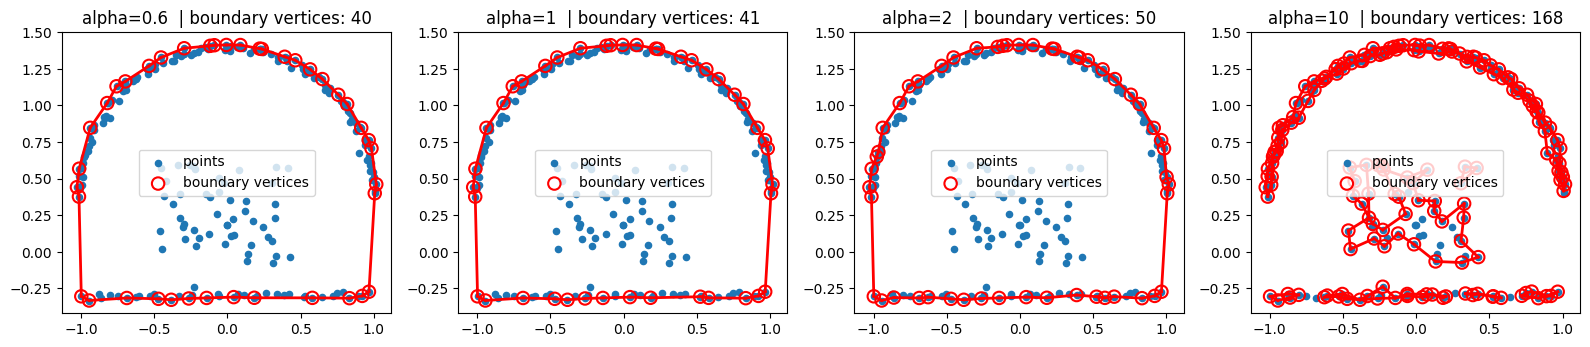

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
from shapely.ops import unary_union
from shapely.geometry import Polygon, LineString

def triangle_circumradius(pa, pb, pc):
    # pa, pb, pc are (2,) arrays
    a = np.linalg.norm(pb - pc)
    b = np.linalg.norm(pc - pa)
    c = np.linalg.norm(pa - pb)
    s = 0.5 * (a + b + c)
    area = max(s * (s - a) * (s - b) * (s - c), 0.0) ** 0.5
    if area == 0:
        return np.inf
    R = (a * b * c) / (4.0 * area)
    return R

def alpha_shape_edges(points, alpha):
    """
    Compute edges that form the alpha-shape boundary for `points` (Nx2).
    Returns:
        boundary_edges: list of (i,j) index pairs referring to points
        interior_triangles_idx: indices of Delaunay triangles accepted by alpha
    """
    pts = np.asarray(points)
    if pts.shape[0] < 3:
        return [], []

    tri = Delaunay(pts)
    triangles = tri.simplices  # (M,3) indices into pts
    kept_tri_mask = np.zeros(len(triangles), dtype=bool)

    # keep triangles with circumradius <= 1/alpha (common convention)
    # If you prefer R < alpha, adapt accordingly.
    threshold = 1.0 / alpha
    for k, t in enumerate(triangles):
        pa, pb, pc = pts[t[0]], pts[t[1]], pts[t[2]]
        R = triangle_circumradius(pa, pb, pc)
        if R <= threshold:
            kept_tri_mask[k] = True

    kept_triangles = triangles[kept_tri_mask]

    # count how many times each undirected edge appears among kept triangles
    from collections import defaultdict
    edge_count = defaultdict(int)
    edge_to_tri = defaultdict(list)

    def key_edge(i, j):
        return (i, j) if i < j else (j, i)

    for ti, tri_indices in enumerate(kept_triangles):
        i, j, k = tri_indices
        for a, b in ((i, j), (j, k), (k, i)):
            edge = key_edge(a, b)
            edge_count[edge] += 1
            edge_to_tri[edge].append(ti)

    # boundary edges are those that appear only once
    boundary_edges = [edge for edge, cnt in edge_count.items() if cnt == 1]
    return boundary_edges, kept_triangles

def plot_alpha_shape(points, alpha, ax=None, show_triangles=False):
    pts = np.asarray(points)
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,6))

    boundary_edges, kept_triangles = alpha_shape_edges(pts, alpha)

    # boundary vertices
    boundary_vertex_indices = sorted(set([i for e in boundary_edges for i in e]))

    # Plot all points
    ax.scatter(pts[:,0], pts[:,1], c='C0', s=20, label='points', zorder=1)

    # highlight boundary vertices
    if len(boundary_vertex_indices) > 0:
        ax.scatter(pts[boundary_vertex_indices,0],
                   pts[boundary_vertex_indices,1],
                   facecolors='none', edgecolors='red', s=80,
                   linewidths=1.5, label='boundary vertices', zorder=3)

    # draw boundary edges
    for (i, j) in boundary_edges:
        ax.plot([pts[i,0], pts[j,0]], [pts[i,1], pts[j,1]], c='red', lw=2, zorder=4)

    # optionally draw kept triangles (transparent)
    if show_triangles and len(kept_triangles) > 0:
        for tri in kept_triangles:
            tri_pts = pts[tri]
            poly = Polygon(tri_pts)
            x,y = poly.exterior.xy
            ax.fill(x, y, facecolor='orange', alpha=0.25, edgecolor='none', zorder=2)

    ax.set_aspect('equal', 'box')
    ax.set_title(f'alpha={alpha:.3g}  | boundary vertices: {len(boundary_vertex_indices)}')
    ax.legend(loc='best')
    return boundary_vertex_indices, boundary_edges

# -------------------------
# Example usage: make a concave / noisy dataset
# -------------------------
if __name__ == "__main__":
    # sample: U-shaped + a few interior points + noise
    t = np.linspace(0, np.pi, 120)
    x = np.cos(t)
    y = np.sin(t) + 0.4
    arch = np.column_stack([x, y])

    # add base
    base_x = np.linspace(-1, 1, 40)
    base_y = np.full_like(base_x, -0.3)
    base = np.column_stack([base_x, base_y])

    pts = np.vstack([arch, base])
    # add small jitter
    rng = np.random.default_rng(1)
    pts = pts + 0.02 * rng.normal(size=pts.shape)

    # add some random interior points
    interior = np.column_stack([rng.uniform(-0.5,0.5,50), rng.uniform(-0.1,0.6,50)])
    pts = np.vstack([pts, interior])

    # plot multiple alphas to see effect
    alphas = [0.6, 1.0, 2.0, 10.0]  # smaller alpha -> finer shape (use convention above)
    fig, axs = plt.subplots(1, len(alphas), figsize=(4*len(alphas), 4))
    for ax, a in zip(axs, alphas):
        plot_alpha_shape(pts, a, ax=ax, show_triangles=False)
    plt.tight_layout()
    plt.show()

In [320]:
def get_window_bins_by_index(edges, window_half=7):
    # edges: np.array of bin edges of length m -> m-1 bins indexed 0..m-2
    n_bins = len(edges) - 1
    if n_bins <= 0:
        return np.array([], dtype=int)
    mid = n_bins // 2
    lo = max(0, mid - window_half)
    hi = min(n_bins - 1, mid + window_half)
    return np.arange(lo, hi + 1)

def choose_alpha_for_points(pts2D):
    """Heuristic alpha: based on median nearest-neighbor distance."""
    pts = np.asarray(pts2D)
    if pts.shape[0] < 4:
        return None
    from scipy.spatial import KDTree
    tree = KDTree(pts)
    dists, _ = tree.query(pts, k=6)
    median_nn = np.median(dists[:, 1:])
    return 1.0 / (median_nn * 1.5 + 1e-9)

def visualize_slice(slice_pts, aps, left_idxs, left, right_idxs, right, top_idxs, top,avg_height_zero, width, height, bin_index,
                    proj_axis_labels=('u','v'),
                    marker_size=4, line_width=1.2, show=True, save_path=None):
    """
    Visualize a 2D slice and its alpha-shape boundary + left/right lines.

    Parameters
    ----------
    slice_pts : (N,2) array-like
        2D points of the slice (projected to the two orthogonal axes).
    aps : alpha points
        Result from alphashape.alphashape(slice_pts, alpha=...), expected to have .exterior.coords
    left, right : float
        Quantile-based left/right x-values (in same coords as slice_pts[:,0]).
    width : float
        Computed width = right - left
    bin_index : int
        Index of the slice (for title / filename)
    proj_axis_labels : tuple(str,str)
        Labels for x/y axes in the plot
    marker_size, line_width : plotting styles
    show : bool
        If True call plt.show() after drawing (set False to only save)
    save_path : str or None
        If provided, will save the figure to this path (PNG).
    """
    fig, ax = plt.subplots(figsize=(6,6))
    slice_pts = np.asarray(slice_pts)
    # scatter points
    if slice_pts.shape[0] > 0:
        ax.scatter(slice_pts[:,0], slice_pts[:,1], s=marker_size, alpha=0.8, label='slice points', c='brown')
    else:
        ax.text(0.5, 0.5, 'empty slice', ha='center')
    
    coords = list(aps)
    xs = [c[0] for c in coords]
    ys = [c[1] for c in coords]
    left_points = np.array(aps)[left_idxs]
    right_points = np.array(aps)[right_idxs]
    top_points = np.array(aps)[top_idxs]
    ax.plot(xs, ys, linewidth=line_width, label='alpha shape', c='black')
    ax.scatter(xs, ys, s=marker_size, label='boundary points', c='green')
    ax.scatter(left_points[:,0], left_points[:,1], marker='x', s=24, label='left side points', c='magenta')
    ax.scatter(right_points[:,0], right_points[:,1], marker='x', s=24, label='right side points', c='cyan')
    ax.scatter(top_points[:,0], top_points[:,1], marker='x', s=24, label='top side points', c='orange')
    # vertical lines for left/right
    ax.axvline(left, linestyle='--', linewidth=2, label=f'left ({left:.3f})')
    ax.axvline(right, linestyle='--', linewidth=2, label=f'right ({right:.3f})')
    ax.axhline(top, linestyle='--', linewidth=2, label=f'top ({top:.3f})')
    ax.axhline(avg_height_zero, linestyle='--', linewidth=2, label=f'bottom ({top:.3f})')
    from matplotlib.patches import Polygon as MPOLY
    from shapely.geometry import Polygon as SPOLY
    poly_xy = SPOLY(slice_pts).convex_hull
    rect_xy = poly_xy.minimum_rotated_rectangle
    poly = MPOLY(rect_xy.exterior.coords, closed=True, edgecolor='r', facecolor='r', alpha=0.2, linewidth=4)
    ax.add_patch(poly)
    # annotate width
    ylim = ax.get_ylim()
    yrange = ylim[1] - ylim[0]
    y_text = ylim[0] + 0.95 * yrange
    ax.text(-0.0, 1, f'slice_start: {bin_index*5}cm; slice_end: {bin_index*5+5}cm; width={width:.3f}m; height={height:.3f}m', transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", fc="w", alpha=0.8))

    ax.set_aspect('equal', 'box')
    ax.set_xlabel(proj_axis_labels[0])
    ax.set_ylabel(proj_axis_labels[1])
    ax.legend(loc='center', fontsize='small')

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150)
    if show:
        plt.show()
    plt.close(fig)

def compute_slices_axis(pile, axis_idx, slice_thickness):
    """
    pile: (N,3) numpy array already aligned so axes are x,y,z
    axis_idx: 0,1,2 the axis to slice along (0 -> x, 1 -> y, 2 -> z)
    slice_thickness: thickness of each slice (same units as points)
    returns: list of per-slice extents (widths), list of slice centers (coordinate)
    """
    coords = pile[:, axis_idx]
    cmin, cmax = coords.min(), coords.max()
    edges = np.arange(cmin, cmax + slice_thickness, slice_thickness)
    if len(edges) < 2:
        return [], []

    bin_idx = np.digitize(coords, edges) - 1
    # clamp points exactly equal to cmax into the last bin
    bin_idx[bin_idx == len(edges)-1] = len(edges)-2

    axes2 = [i for i in (0,1,2) if i != axis_idx]

    widths = []
    heights = []
    selected_bins = get_window_bins_by_index(edges, window_half=4)
    for b in selected_bins:
        mask = (bin_idx == b)
        if not np.any(mask):
            continue
        slice_pts = pile[mask][:, axes2]
        rot_slice = rotate_slice(slice_pts)
        bottom_x = np.arange(np.min(rot_slice[:,0])+0.2, np.max(rot_slice[:,0])-0.2, 0.1)
        # adding points for alpha shape inward blocking.
        bottom_y = np.tile([np.min(rot_slice[:,1]), np.min(rot_slice[:,1]+0.1)], len(bottom_x))
        shape_pts = np.array(list(zip(bottom_x, bottom_y)))
        updated_rot_slice = np.vstack((rot_slice, shape_pts))
        try:
            hull = alphashape.alphashape(updated_rot_slice, alpha=2)
            if hasattr(hull, "geoms") and len(hull.geoms) > 1:
                raise Exception('Failed to segment! Severe cut-outs present!')
            alpha_points = hull.exterior.coords
            xs = np.array([x[0] for x in alpha_points])
            ys = np.array([x[1] for x in alpha_points])
            # width computation
            l_min = np.min(xs)
            l_max = l_min + 0.2
            top_max = np.max(ys)
            top_min = top_max - 0.2
            left_idxs = np.array([i for i in range(len(alpha_points)) if xs[i] > l_min and xs[i] < l_max and ys[i] < top_min])
            left = np.mean(xs[left_idxs])

            r_max = np.max(xs)
            r_min = r_max - 0.2
            right_idxs = np.array([i for i in range(len(xs)) if xs[i] > r_min and xs[i] < r_max and ys[i] < top_min])
            right = np.mean(xs[right_idxs])
            
            # height computation
            bottom_left = np.min(ys[left_idxs])
            bottom_right = np.min(ys[right_idxs])
            avg_height_zero = (bottom_left + bottom_right) / 2
            top_idxs = np.array([i for i in range(len(alpha_points)) if ys[i] > (top_min-0.1) and xs[i] < r_min and xs[i] > l_max])
            top = np.mean(ys[top_idxs])
            
            width = right - left
            height = top - avg_height_zero
            heights.append(height)
            widths.append(width)
            if b == np.median(selected_bins):
                visualize_slice(rot_slice, alpha_points, left_idxs, left, right_idxs, right, top_idxs, top, avg_height_zero, width, height, b,
                    proj_axis_labels=('axis 1','axis 2'),
                    show=True,
                    save_path=f'DATA/slice_{b}.png')
            # print(f'Processed bin {b}')
        except Exception as e:
            print(f'error {e}')
            # left = np.percentile(xs, quantile_low)
            # right = np.percentile(xs, quantile_high)
            # width = right - left
            # widths.append(width)
            pass
        
    return widths, heights

def aggregate_dims(widths, heights):
    if not widths or not heights:
        return None, None
    widths = np.array(widths)
    heights = np.array(heights)
    median_w = np.median(widths)
    median_h = np.median(heights)
    mad_w = np.median(np.abs(widths - median_w))
    mad_h = np.median(np.abs(heights - median_h))
    mean_w = np.mean(widths)
    mean_h = np.mean(heights)
    # trimmed mean: remove trim_fraction from each tail
    return {"width_median": median_w, "width_mad": mad_w, "width_mean": mean_w,
            "width_count": len(widths), "width_min": widths.min(), "width_max": widths.max(),
            "height_median": median_h, "height_mad": mad_h, "height_mean": mean_h,
            "height_count": len(heights), "height_min": heights.min(), "height_max": heights.max()}

def pca_3_components(pts):
    centroid_2d = pts[:,:2].mean(axis=0)
    Y_2d = np.array(pts[:,:2] - centroid_2d)
    poly = Polygon(Y_2d).convex_hull
    rect = poly.minimum_rotated_rectangle
    coords = np.array(rect.exterior.coords)[:-1]
    edges = coords[1:] - coords[0:-1]
    pc1 = edges[0] / np.linalg.norm(edges[0])
    pc2 = edges[1] / np.linalg.norm(edges[1])
    pc1_3d = np.array([pc1[0], pc1[1], 0.0])
    pc2_3d = np.array([pc2[0], pc2[1], 0.0])
    pc3_3d = -np.cross(pc1_3d, pc2_3d)
    components = np.column_stack([ pc1_3d, pc2_3d ,pc3_3d])
    R = components.T
    centroid_3d = pts.mean(axis=0)
    Y = np.array(pts - centroid_3d)
    pts_rot = Y @ R
    return pts_rot

def detect_empty_edge(points, tol=0.3, margin=0.1):
    x_min, y_min = points.min(axis=0)
    x_max, y_max = points.max(axis=0)
    # Count points within tol of each edge (ignoring small corner margins)
    left_mask   = (np.abs(points[:,0] - x_min) <= tol) & (points[:,1] > (y_min + margin)) & (points[:,1] < (y_max - margin))
    right_mask  = (np.abs(points[:,0] - x_max) <= tol) & (points[:,1] > (y_min + margin)) & (points[:,1] < (y_max - margin))
    bottom_mask = (np.abs(points[:,1] - y_min) <= tol) & (points[:,0] > (x_min + margin)) & (points[:,0] < (x_max - margin))
    top_mask    = (np.abs(points[:,1] - y_max) <= tol) & (points[:,0] > (x_min + margin)) & (points[:,0] < (x_max - margin))
    counts = {
        'left':   left_mask.sum(),
        'right':  right_mask.sum(),
        'top':    top_mask.sum(),
        'bottom': bottom_mask.sum()
    }

    empty_edge = min(sorted(counts.items()), key=lambda kv: (kv[1], kv[0]))[0]
    return empty_edge

def align_axis(points):
    pts = np.asarray(points, dtype=float)
    centroid_2d = pts[:,:2].mean(axis=0)
    Y_2d = np.array(pts[:,:2] - centroid_2d)
    # standard rotation
    poly_xy = Polygon(Y_2d).convex_hull
    rect_xy = poly_xy.minimum_rotated_rectangle
    coords_xy = np.array(rect_xy.exterior.coords)[:-1]
    edges_xy = coords_xy[1:] - coords_xy[0:-1]
    pc1 = edges_xy[0] / np.linalg.norm(edges_xy[0])
    pc2 = np.array([-pc1[1], pc1[0]]) # (-y, x) - perpendicular vector
    pc1 = pc1 / np.linalg.norm(pc1)
    pc2 = pc2 / np.linalg.norm(pc2)
    R = np.column_stack((pc1, pc2))
    pts_rot = Y_2d @ R
    return pts_rot

def rotate_slice(points):
    pts_rot = align_axis(points)
    bottom_edge = detect_empty_edge(pts_rot)
    rotate_map = {'bottom': 0.0, 'top': np.pi, 'left': np.pi/2, 'right': -np.pi/2}
    extra_angle = rotate_map[bottom_edge]
    R = np.array([[np.cos(extra_angle), -np.sin(extra_angle)],
                  [np.sin(extra_angle),  np.cos(extra_angle)]])
    return pts_rot @ R.T

def mask_to_bool(mask):
    try:
        if isinstance(mask, torch.Tensor):
            mask = mask.detach().cpu().numpy()
    except Exception:
        pass
    mask = np.asarray(mask)
    # typical shape possibilities: (1,H,W), (H,W), (H,W,1)
    if mask.ndim == 3 and mask.shape[0] == 1:
        mask = mask[0]
    if mask.ndim == 3 and mask.shape[2] == 1:
        mask = mask[...,0]
    return mask.astype(bool)

def build_mask_img(img_np, inference_state):
    masks = inference_state["masks"]
    nb_objects = len(inference_state.get("scores", masks))

    H, W = img_np.shape[:2]

    for i in range(nb_objects):
        m_raw = masks[i]
        mask = mask_to_bool(m_raw)  # HxW bool
        if mask.shape != (H, W):
            raise ValueError(f"mask {i} has shape {mask.shape} but image is {(H,W)}")

        color_arr = np.array([255,0,0])
        fg = np.broadcast_to(color_arr, img_np.shape).astype(np.float32)
        mask_idx = mask
        blended = (fg ).astype(np.uint8)
        img_np[mask_idx] = blended[mask_idx]
    return img_np

def classify_point_cloud(image, point_cloud, mapping):
    h, w = image.shape[:2]
    if (point_cloud.shape[1] == 3):
        init_pc_classes = np.zeros((point_cloud.shape[0],1))
        modified_point_cloud = np.hstack((point_cloud, init_pc_classes))
    else:
        modified_point_cloud = point_cloud
    for iy in range(h):
        for ix in range(w):
            point_index = mapping[iy, ix]
            if point_index != -1:
                color = image[iy, ix]
                cl = 1 if (color == [255,0,0]).all() else 0 
                modified_point_cloud[point_index, 3] = cl
    return modified_point_cloud

def keep_top_k_clusters(points, idxs,  k=4, keep_k_largest=4):
    """
    Cluster with KMeans into k clusters (k should be >= keep_k_largest).
    Keep only points belonging to the largest `keep_k_largest` clusters.
    """
    pts = np.asarray(points)
    k = max(k, keep_k_largest)
    km = KMeans(n_clusters=k, random_state=0).fit(pts)
    labels = km.labels_
    # count sizes
    unique, counts = np.unique(labels, return_counts=True)
    # sort cluster ids by size descending
    cluster_order = unique[np.argsort(-counts)]
    keep_clusters = set(cluster_order[:keep_k_largest])
    mask = np.isin(labels, list(keep_clusters))
    pts_kept = pts[mask]
    idxs_kept = idxs[mask]
    labels_kept = labels[mask]
    return pts_kept, idxs_kept, labels_kept

from sklearn.cluster import DBSCAN

def remove_outliers_dbscan(points, idxs, eps=0.03, min_samples=10):
    """
    Remove sparse noise using DBSCAN (keeps core + border points, drops -1 labels).
    points: (N,2) or (N,3) numpy array
    eps: neighborhood radius (tune based on units of data)
    min_samples: minimum neighbors to form a core point
    Returns: filtered_points (Mxd)
    """
    pts = np.asarray(points)
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(pts)
    labels = db.labels_
    # label -1 is noise
    mask = labels != -1
    return pts[mask], idxs[mask]

def build_cluster_image(point_cloud, colors, view='y', img_height=480, img_width=640, pad_frac=0.001):
    pts = np.asarray(point_cloud)
    if pts.size == 0:
        image = np.ones((img_height, img_width, 3), dtype=np.uint8) * 255
        mapping2d = np.full((img_height, img_width), -1, dtype=np.int64)
        return image, mapping2d

    if view == 'y':
        u_axis, v_axis, depth_axis = 0, 2, 1
    elif view == 'z':
        u_axis, v_axis, depth_axis = 0, 1, 2
    else:
        u_axis, v_axis, depth_axis = 1, 2, 0

    u_vals = pts[:, u_axis].astype(np.float64)
    v_vals = pts[:, v_axis].astype(np.float64)
    depth_vals = pts[:, depth_axis].astype(np.float64)
    u_min, u_max = float(u_vals.min()), float(u_vals.max())
    v_min, v_max = float(v_vals.min()), float(v_vals.max())
    # x_min, x_max = x.min(), x.max()
    # z_min, z_max = z.min(), z.max()
    du = (u_max - u_min)
    dv = (v_max - v_min)
    if du == 0:
        du = 1e-9
    if dv == 0:
        dv = 1e-9
    pad_u = pad_frac * du + 1e-12
    pad_v = pad_frac * dv + 1e-12
    u_min -= pad_u; u_max += pad_u
    v_min -= pad_v; v_max += pad_v
    u_pix = np.floor((u_vals - u_min) / (u_max - u_min) * (img_width - 1)).astype(np.int64)
    v_pix = np.floor((v_vals - v_min) / (v_max - v_min) * (img_height - 1)).astype(np.int64)
    v_pix = img_height - 1 - v_pix
    valid = (u_pix >= 0) & (u_pix < img_width) & (v_pix >= 0) & (v_pix < img_height)
    if not np.any(valid):
        # nothing projects into image
        img = np.zeros((img_height, img_width, 3), dtype=np.uint8)
        mapping2d = np.full((img_height, img_width), -1, dtype=np.int64)
        return img, mapping2d

    u_sel = u_pix[valid]; v_sel = v_pix[valid]
    depth_sel = depth_vals[valid]
    idxs = np.nonzero(valid)[0]

    flat_idx = v_sel * img_width + u_sel

    # pick the point with maximum depth per pixel (same convention as original: max depth)
    # sort by (flat_idx primary, -depth secondary) so highest depth comes first for each pixel
    order = np.lexsort(( -depth_sel, flat_idx ))
    sorted_flat = flat_idx[order]

    new_pixel_mask = np.empty_like(sorted_flat, dtype=bool)
    new_pixel_mask[0] = True
    if sorted_flat.shape[0] > 1:
        new_pixel_mask[1:] = sorted_flat[1:] != sorted_flat[:-1]

    # indices (into the valid-point set) chosen for each occupied pixel
    first_in_sorted = order[new_pixel_mask]      # indices into the valid arrays
    chosen_flat_idx = flat_idx[first_in_sorted]  # flat pixel indices chosen
    chosen_point_indices = idxs[first_in_sorted]
    n_pixels = img_width * img_height
    mapping = np.full(n_pixels, -1, dtype=np.int64)   # flat mapping -> point index
    mapping[chosen_flat_idx] = chosen_point_indices
    # Create image and reshape mapping to 2D
    image = np.ones((img_height, img_width, 3), dtype=np.uint8) * 255
    mapping2d = mapping.reshape((img_height, img_width))
    chosen_y = chosen_flat_idx // img_width
    chosen_x = chosen_flat_idx % img_width
    image[chosen_y, chosen_x] = colors[chosen_point_indices]

    return image, mapping2d

def build_clusters(point_cloud, colors_all):
    pts_all = point_cloud[:, :3]
    mask_idx = np.nonzero(point_cloud[:,3])[0]
    segmented_points = pts_all[mask_idx]
    clustered_temp, idxs1 = remove_outliers_dbscan(segmented_points, mask_idx, eps=0.03, min_samples=10)
    clustered, idxs2 = remove_outliers_dbscan(clustered_temp, idxs1, eps=0.2, min_samples=100)
    clustered, clustered_idxs, labelled = keep_top_k_clusters(clustered, idxs2)
    unique_labels = np.unique(labelled)
    unique_labels = unique_labels[unique_labels != -1]
    clusters = []
    cl_centroids = []
    cluster_mappings2d = []
    for lab in unique_labels:
        maskc = labelled == lab
        cl = clustered[maskc]
        if cl.shape[0] == 0:
            continue
        clusters.append(cl)                 # keep as list of arrays
        cl_centroids.append(cl.mean(axis=0))
    return clusters, cl_centroids

def order_clusters(point_cloud, clusters, cl_centroids):
    cl_centroids = np.array(cl_centroids)   # (K,3)

    # order clusters by x (ascending)
    cl_order = np.argsort(cl_centroids[:, 0])

    min_truck_x = np.min(point_cloud[:,0])
    left_cluster = clusters[cl_order[0]]
    min_x_left_cl = np.min(left_cluster[:, 0])
    if min_truck_x > (min_x_left_cl - 0.3):
        cl_order = cl_order[::-1]
    return cl_order

def mask_iou(mask_a, mask_b):
    # boolean numpy arrays same shape
    inter = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a, mask_b).sum()
    return 0.0 if union == 0 else inter / union

def mask_nms(masks, scores, iou_thresh=0.5):
    # masks: list/array of boolean arrays, scores: numpy array (N,)
    order = np.argsort(scores)[::-1]
    keep = []
    while order.size:
        i = order[0]
        keep.append(i)
        if order.size == 1:
            break
        rest = order[1:]
        ious = np.array([mask_iou(masks[i], masks[j]) for j in rest])
        order = rest[ious <= iou_thresh]
    return np.array(keep, dtype=int)

def cluster_timber_logs(img):
    pim = Image.fromarray(img)
    inference_state = processor.set_image(pim)
    processor.reset_all_prompts(inference_state)
    inference_state = processor.set_text_prompt(state=inference_state, prompt="woodlog")
    masks = inference_state['masks']
    np_masks = masks.permute(1,0,2,3).squeeze().detach().cpu().numpy()
    to_keep = mask_nms(np_masks, inference_state['scores'].detach().cpu().numpy())
    sorted_masks = sorted(np_masks[to_keep], key=lambda x: len(x[x]), reverse=True)
    grouped_labels = []
    fig, ax = plt.subplots(figsize=(6,6))
    # plt.imshow(img)
    log_masks= []
    for mask_id in range(len(sorted_masks)):
        if mask_id in grouped_labels:
            continue
        # print(f'Analysing mask:{mask_id}')
        group = [mask_id]
        grouped_labels.append(mask_id)
        analysed_mask = sorted_masks[mask_id]
        H,W = analysed_mask.shape
        ys, xs = np.where(analysed_mask)
        coords_xy = np.column_stack((xs, ys)).astype(float)  # (x,y)
        centroid = coords_xy.mean(axis=0)
        centered = coords_xy - centroid
        U, S, Vt = np.linalg.svd(centered, full_matrices=False)
        pc1 = Vt[0]
        pc1 = pc1 / np.linalg.norm(pc1)
        projections = centered.dot(pc1)
        min_proj = projections.min()
        max_proj = projections.max()
        endpoint_left = centroid + pc1 * min_proj
        endpoint_right = centroid + pc1 * max_proj
        line_pts= []
        analysis_img = np.ones_like(analysed_mask, dtype=np.int32)*-1
        for c_mask_id in range(len(sorted_masks)):
            if c_mask_id in grouped_labels:
                continue
            c_mask = sorted_masks[c_mask_id]
            analysis_img[c_mask] = c_mask_id

        def march_ray(dir_vec, start_xy):
            n_steps = int(max(W,H))
            for i in range(1, n_steps + 1):
                dist_from_endpoint = i
                point_xy = start_xy + dir_vec * dist_from_endpoint
                sx = int(round(point_xy[0])); sy = int(round(point_xy[1]))
                if sx < 0 or sx >= W or sy < 0 or sy >= H:
                    break
                found_label = None
                line_pts.append(np.array([sy,sx]))
                lbl = int(analysis_img[sy, sx])
                if lbl != -1 and lbl != mask_id and lbl not in grouped_labels and lbl not in group:
                    # print(f'found label {lbl}')
                    found_label = lbl
                    grouped_labels.append(found_label)
                    group.append(found_label)

        # print('moving to the right')
        march_ray(pc1, centroid)
        # print('moving to the left')
        march_ray(-pc1, centroid)
        # groups.append(group)
        # print(img.shape)
        merged_mask = np.zeros((480,640))
        # print(group)
        for g_mask_id in group:
            g_mask = sorted_masks[g_mask_id]
            merged_mask[g_mask] = 1
        merged_mask = merged_mask.astype(bool)
        g_color = np.random.randint(0, 256, size=3)
        fg = np.broadcast_to(g_color, img.shape).astype(np.uint8)
        
        img[merged_mask] = fg[merged_mask]
        line_ptsa=np.array(line_pts)
        
        if len(line_ptsa) >0 :
            # ax.scatter(line_ptsa[:,1], line_ptsa[:,0], s=1, alpha=0.8, label='slice points', c='red')
            ax.scatter(centroid[0], centroid[1], s=8, alpha=0.8, label='slice points', c='blue')
            ax.text(centroid[0], centroid[1], mask_id, color="black", fontsize=14, weight='bold')
        log_masks.append((mask_id, merged_mask))
    plt.imshow(img)
    plt.show()
    return log_masks
    

def analyse_lengths(cl, point_cloud, colors_all):
    invalid_logs = []
    all_logs = []

    full_pc_mask = (
        (point_cloud[:,0] >= np.min(cl[:, 0])-0.3) & (point_cloud[:,0] <= np.max(cl[:, 0])+0.3) &
        (point_cloud[:,1] >= np.max(cl[:, 1])-0.3) & (point_cloud[:,1] <= np.max(cl[:, 1])+0.3) &
        (point_cloud[:,2] >= np.min(cl[:, 2])-0.1) & (point_cloud[:,2] <= np.max(cl[:, 2])+0.5)
    )

    im_cl_global_idxs = np.nonzero(full_pc_mask)[0]
    im_cl = point_cloud[full_pc_mask]
    cl_colors = colors_all[full_pc_mask]
    image, mapping2d = build_cluster_image(im_cl, cl_colors)
    log_masks = cluster_timber_logs(image)
    for log_id, log_mask in log_masks:
        local_idxs = mapping2d[log_mask]
        global_idxs = im_cl_global_idxs[local_idxs]
        log = point_cloud[global_idxs]
        log_length = max(log[:,0]) - min(log[:,0])
        print(f'Length of log {log_id} is {log_length}')
        all_logs.append(log_length)
        if log_length < 2.444 and log_length > 2:
            invalid_logs.extend(list(log))

    full_pc_mask = (
        (point_cloud[:,0] >= np.min(cl[:, 0])-0.3) & (point_cloud[:,0] <= np.max(cl[:, 0])+0.3) &
        (point_cloud[:,1] >= np.min(cl[:, 1])-0.3) & (point_cloud[:,1] <= np.min(cl[:, 1])+0.3) &
        (point_cloud[:,2] >= np.min(cl[:, 2])-0.1) & (point_cloud[:,2] <= np.max(cl[:, 2])+0.5)
    )

    im_cl_global_idxs = np.nonzero(full_pc_mask)[0]
    im_cl = point_cloud[full_pc_mask]
    cl_colors = colors_all[full_pc_mask]
    image, mapping2d = build_cluster_image(im_cl, cl_colors)
    log_masks = cluster_timber_logs(image)
    for log_id, log_mask in log_masks:
        local_idxs = mapping2d[log_mask]
        global_idxs = im_cl_global_idxs[local_idxs]
        log = point_cloud[global_idxs]
        log_length = max(log[:,0]) - min(log[:,0])
        print(f'Length of log {log_id} is {log_length}')
        all_logs.append(log_length)
        if log_length < 2.444 and log_length > 2:
            invalid_logs.extend(list(log))

    full_pc_mask = (
        (point_cloud[:,0] >= np.min(cl[:, 0])-0.3) & (point_cloud[:,0] <= np.max(cl[:, 0])+0.3) &
        (point_cloud[:,1] >= np.min(cl[:, 1])-0.3) & (point_cloud[:,1] <= np.max(cl[:, 1])+0.3) &
        (point_cloud[:,2] >= np.max(cl[:, 2])-0.3) & (point_cloud[:,2] <= np.max(cl[:, 2])+0.3)
    )

    im_cl_global_idxs = np.nonzero(full_pc_mask)[0]
    im_cl = point_cloud[full_pc_mask]
    cl_colors = colors_all[full_pc_mask]
    image, mapping2d = build_cluster_image(im_cl, cl_colors, view='z')
    log_masks = cluster_timber_logs(image)
    for log_id, log_mask in log_masks:
        local_idxs = mapping2d[log_mask]
        global_idxs = im_cl_global_idxs[local_idxs]
        log = point_cloud[global_idxs]
        log_length = max(log[:,0]) - min(log[:,0])
        print(f'Length of log {log_id} is {log_length}')
        all_logs.append(log_length)
        if log_length < 2.444 and log_length > 2:
            invalid_logs.extend(list(log))

    avg_length = np.array(all_logs).mean()
    return invalid_logs, avg_length

        # header = laspy.LasHeader(point_format=3, version="1.2")
        # header.add_extra_dim(laspy.ExtraBytesParams(name="random", type=np.int32))
        # las_o = laspy.LasData(header)
        # las_o.x = log[:, 0]
        # las_o.y = log[:, 1]
        # las_o.z = log[:, 2]

        # las_o.classification = log[:, 3].astype(np.uint8)

        # las_o.write(f'{log_id}_test.las')
    # Image.fromarray(image).show()


def export_point_cloud(cloud_path, modified_point_cloud, colors_all):
    header = laspy.LasHeader(point_format=3, version="1.2")
    header.add_extra_dim(laspy.ExtraBytesParams(name="random", type=np.int32))
    

    # find 4 clusters
    clusters, cl_centroids = build_clusters(modified_point_cloud, colors_all)
    # order clusters
    cl_order = order_clusters(modified_point_cloud, clusters, cl_centroids)

    if len(clusters) == 0:
        raise ValueError("No valid clusters to export")

    stacked_list = []
    res_dicts = []
    all_invalid = []
    for out_idx, idx_in_order in enumerate(cl_order, start=1):
        cl = clusters[idx_in_order]
        try:
            # analytics
            print(f'Processing pile #{out_idx}')
            w_x, h_y = compute_slices_axis(cl, axis_idx=0, slice_thickness=0.05)
            res_dims = aggregate_dims(w_x, h_y)
            invalid_logs, avg_length = analyse_lengths(cl, modified_point_cloud, colors_all)
            all_invalid.extend(invalid_logs)
            res_dims['avg_length'] = avg_length
            print(res_dims)
            res_dicts.append(res_dims)
            print()
        except Exception as e:
            # not fatal — continue
            print(e)
            pass
        
        cls_col = np.full((cl.shape[0], 1), out_idx, dtype=np.uint8)
        pts_with_cls = np.concatenate([cl, cls_col], axis=1)  # (n,4)
        stacked_list.append(pts_with_cls)

    all_pts = np.vstack(stacked_list)   # (M,4)

    las_o = laspy.LasData(header)
    las_o.x = modified_point_cloud[:, 0]
    las_o.y = modified_point_cloud[:, 1]
    las_o.z = modified_point_cloud[:, 2]
    red16   = (colors_all[:, 0].astype(np.uint16) * 257)
    green16 = (colors_all[:, 1].astype(np.uint16) * 257)
    blue16  = (colors_all[:, 2].astype(np.uint16) * 257)
    las_o.red   = red16
    las_o.green = green16
    las_o.blue  = blue16
    las_o.write(cloud_path)
    
    all_invalid = np.array(all_invalid)
    las_o = laspy.LasData(header)
    las_o.x = all_invalid[:, 0]
    las_o.y = all_invalid[:, 1]
    las_o.z = all_invalid[:, 2]
    red16   = (np.repeat([255], len(all_invalid)).astype(np.uint16) * 257)
    green16 = (np.repeat([0], len(all_invalid)).astype(np.uint16) * 257)
    blue16  = (np.repeat([0], len(all_invalid)).astype(np.uint16) * 257)
    las_o.red   = red16
    las_o.green = green16
    las_o.blue  = blue16
    las_o.write('DATA/invalid_logs_range.las')
    df = pd.DataFrame(res_dicts)
    df.to_csv('results.csv')
    print(f"Wrote {all_pts.shape[0]} points to {cloud_path}")
    # components, centroid, points_rot = pca_3_components(cl0)
    # cylinders_to_las(centroid, components,
    #                  out_path="DATA/pca_cylinders.las",
    #                  radius=0.5,
    #                  height=12.0,
    #                  points_per_ring=128,
    #                  rings_along=200,
    #                  classification_start=4)
    # axis-0: projecting points to YZ axis (computing width and height)
    # w_x, centers_x = compute_slices_axis(cl0, axis_idx=0, slice_thickness=t)
    # res_x = aggregate_widths(w_x)
    # select only non-zero-classification points
    # x_sel = clustered[:, 0]
    # y_sel = clustered[:, 1]
    # z_sel = clustered[:, 2]
    # cl = labelled
    
    # las_o.x = all[:,0]
    # las_o.y = all[:,1]
    # las_o.z = all[:,2]
    # las_o.classification = all[:,3]
    # las_o.write(cloud_path)

def _orthonormal_frame_from_axis(axis):
    """
    Given a 3-vector axis (unit), return two orthonormal vectors u,v
    forming a right-handed frame (u,v,axis).
    """
    axis = np.asarray(axis, dtype=float)
    axis = axis / np.linalg.norm(axis)
    # pick arbitrary vector not parallel to axis
    if abs(axis[2]) < 0.9:
        arb = np.array([0.0, 0.0, 1.0])
    else:
        arb = np.array([0.0, 1.0, 0.0])
    u = np.cross(axis, arb)
    u /= np.linalg.norm(u)
    v = np.cross(axis, u)
    v /= np.linalg.norm(v)
    return u, v

def cylinders_to_las(centroid,
                     components,
                     out_path="pca_cylinders.las",
                     radius=0.5,
                     height=10.0,
                     points_per_ring=64,
                     rings_along=100,
                     classification_start=100):
    """
    Create cylinders along PCA component directions and write a LAS.

    Args:
      centroid: array-like (3,) - centroid position [x,y,z]
      components: (3,3) array where each row is a PCA unit vector (PC1,PC2,PC3)
      out_path: output LAS file path
      radius: cylinder radius (meters). For 1m diameter use radius=0.5
      height: cylinder length (meters)
      points_per_ring: angular resolution (points per circular ring)
      rings_along: number of rings along cylinder height (axial resolution)
      classification_start: base classification value; cylinder i gets classification_start+i

    Returns:
      writes LAS file to out_path and returns (X, Y, Z, class_array) as numpy arrays
    """
    centroid = np.asarray(centroid, dtype=float)
    components = np.asarray(components, dtype=float)
    assert components.shape == (3,3), "components must be (3,3) array (rows = PC1,PC2,PC3)"

    all_pts = []
    all_cls = []

    half_h = float(height) / 2.0
    zs = np.linspace(-half_h, half_h, rings_along)

    angles = np.linspace(0.0, 2.0*np.pi, points_per_ring, endpoint=False)

    for i in range(3):
        axis = components[i]
        # make sure axis is unit
        axis = axis / np.linalg.norm(axis)
        u, v = _orthonormal_frame_from_axis(axis)  # two perpendicular directions in cylinder plane

        cls_val = int(classification_start + i)

        # for each ring along axis:
        for zpos in zs:
            center = centroid + axis * zpos
            # generate ring points
            cos_a = np.cos(angles)
            sin_a = np.sin(angles)
            ring_pts = center[np.newaxis, :] + radius * (np.outer(cos_a, u) + np.outer(sin_a, v))
            # ring_pts shape (points_per_ring, 3)
            all_pts.append(ring_pts)
            all_cls.append(np.full((points_per_ring,), cls_val, dtype=np.uint8))

    if not all_pts:
        raise RuntimeError("No points generated (check parameters).")

    pts_arr = np.vstack(all_pts)  # (M,3)
    cls_arr = np.hstack(all_cls).astype(np.uint8)  # (M,)

    # Create LAS header and LasData (laspy v2)
    header = laspy.LasHeader(point_format=3, version="1.2")
    # optional: adjust scales/offsets to preserve float coords nicely
    # header.scales = np.array([0.001, 0.001, 0.001])  # if you want millimeter precision
    # header.offsets = np.array([0.0, 0.0, 0.0])
    las = laspy.LasData(header)

    # assign coordinates (laspy accepts float arrays for x,y,z)
    las.x = pts_arr[:, 0]
    las.y = pts_arr[:, 1]
    las.z = pts_arr[:, 2]

    # safe-assign classification (uint8)
    las.classification = cls_arr

    # write file
    las.write(out_path)
    print(f"Wrote {pts_arr.shape[0]} points to {out_path} with classifications {classification_start}, {classification_start+1}, {classification_start+2}")

def segment_pc(spherical_image, mapping, point_cloud):
    pim = Image.fromarray(spherical_image)
    inference_state = processor.set_image(pim)
    processor.reset_all_prompts(inference_state)
    inference_state = processor.set_text_prompt(state=inference_state, prompt="pile")
    img_np = np.array(pim).astype(np.uint8) 
    img_np = build_mask_img(img_np, inference_state)
    plot_results(pim, inference_state)
    return classify_point_cloud(img_np, point_cloud, mapping)

def collect_points(perspectives, init_pc, resolution):
    modified_pc = init_pc
    # rotation around x axis
    Rx_neg90 = np.array([
        [1, 0, 0],
        [0, 0, 1],
        [0, -1, 0]
    ])
    rotated_pc = init_pc[:,:3].dot(Rx_neg90.T)

    for center in perspectives:
        spherical_image, mapping = generate_spherical_image_fast(center, init_pc, colors, resolution)
        modified_pc = segment_pc(spherical_image, mapping, modified_pc)
        if center[1] > 0: # we need only top coords - do not go under the truck
            spherical_image, mapping = generate_spherical_image_fast(center, rotated_pc, colors, resolution)
            modified_pc = segment_pc(spherical_image, mapping, modified_pc)

    return modified_pc


Processing pile #1


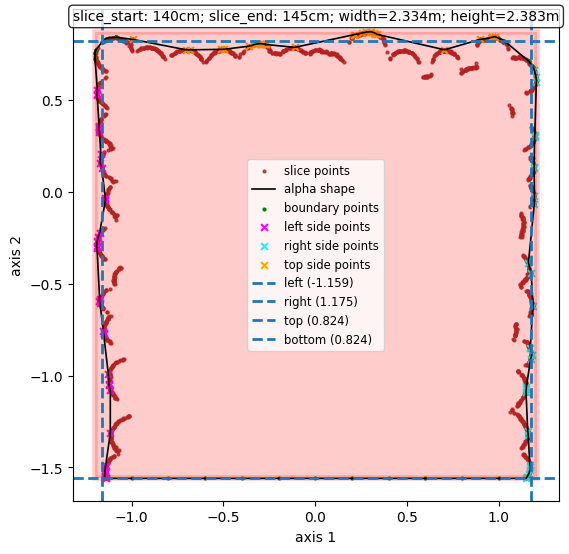

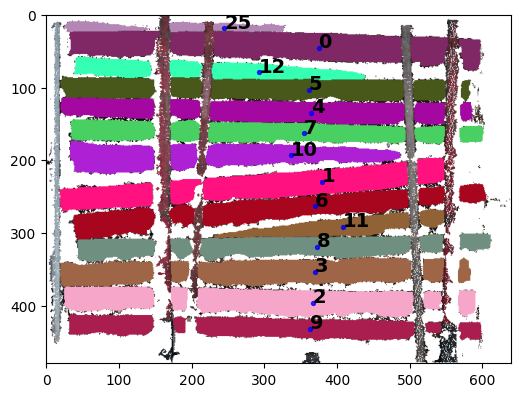

Length of log 0 is 2.52501038603229
Length of log 1 is 2.4450359686168976
Length of log 2 is 2.5217348959532893
Length of log 3 is 2.514904880959629
Length of log 4 is 2.527224222515068
Length of log 5 is 2.5121559783314305
Length of log 6 is 2.5332887010566454
Length of log 7 is 2.5323505231885988
Length of log 8 is 2.537649011308483
Length of log 9 is 2.5275059509125803
Length of log 10 is 2.380151714000438
Length of log 11 is 1.4938526462757133
Length of log 12 is 2.358422175165461
Length of log 25 is 2.417429326206687


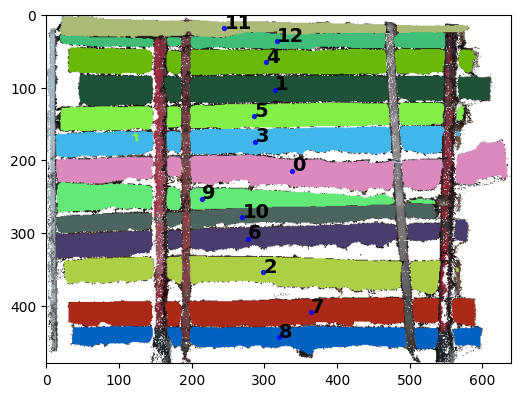

Length of log 0 is 2.799923304331379
Length of log 1 is 2.5560591370787864
Length of log 2 is 2.4766299039695827
Length of log 3 is 2.530006083681367
Length of log 4 is 2.5266856528320525
Length of log 5 is 2.512972630273173
Length of log 6 is 2.555344985444883
Length of log 7 is 2.5253361697737957
Length of log 8 is 2.5431394413976562
Length of log 9 is 2.521866433750236
Length of log 10 is 2.5265122210775184
Length of log 11 is 2.5331749519844027
Length of log 12 is 2.504295640003548


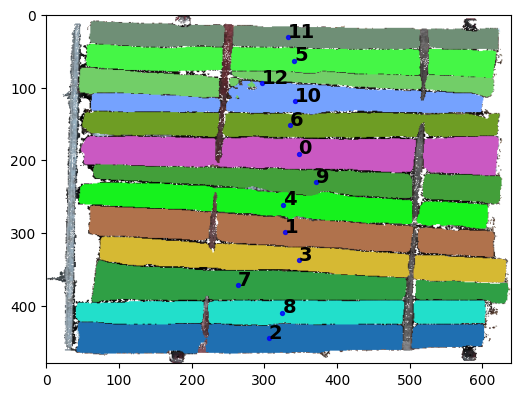

Length of log 0 is 2.57962798988527
Length of log 1 is 2.502185416750302
Length of log 2 is 2.5166735113800374
Length of log 3 is 2.5086700053883133
Length of log 4 is 2.525297653524351
Length of log 5 is 2.529057969430236
Length of log 6 is 2.5744415115752637
Length of log 7 is 2.5713075227525337
Length of log 8 is 2.5296103574181377
Length of log 9 is 2.5211211979171977
Length of log 10 is 2.420675978293186
Length of log 11 is 2.523089746608257
Length of log 12 is 2.559091139152332
{'width_median': np.float64(2.3344164398988156), 'width_mad': np.float64(0.002689527526122948), 'width_mean': np.float64(2.333910302229639), 'width_count': 9, 'width_min': np.float64(2.3255434059753712), 'width_max': np.float64(2.3411472042035255), 'height_median': np.float64(2.3832506050294437), 'height_mad': np.float64(0.009045633388841345), 'height_mean': np.float64(2.387403758831315), 'height_count': 9, 'height_min': np.float64(2.3742049716406024), 'height_max': np.float64(2.401956963522905), 'avg_leng

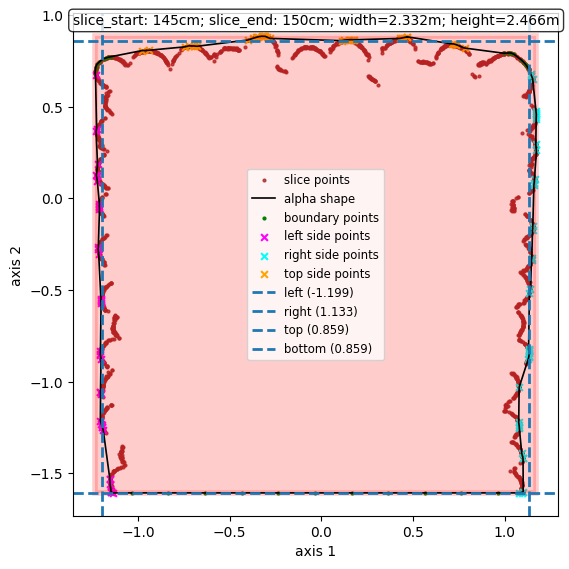

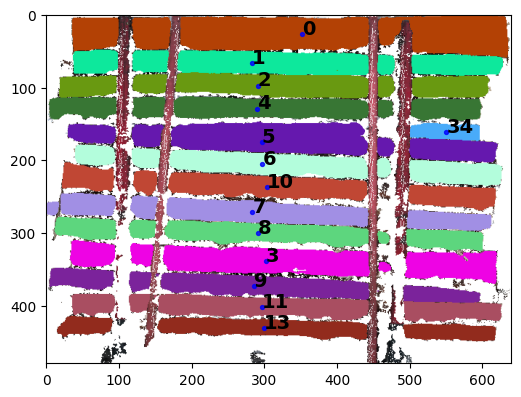

Length of log 0 is 2.5521308902589497
Length of log 1 is 2.5155511665886836
Length of log 2 is 2.5660014031227116
Length of log 3 is 2.501826503883062
Length of log 4 is 2.6246082311155683
Length of log 5 is 2.515648450372771
Length of log 6 is 2.498673414889162
Length of log 7 is 2.6387558951310273
Length of log 8 is 2.5889832634081733
Length of log 9 is 2.6211843967885238
Length of log 10 is 2.5482401698903607
Length of log 11 is 2.5169553535067477
Length of log 13 is 2.574952966531782
Length of log 34 is 0.510988534326944


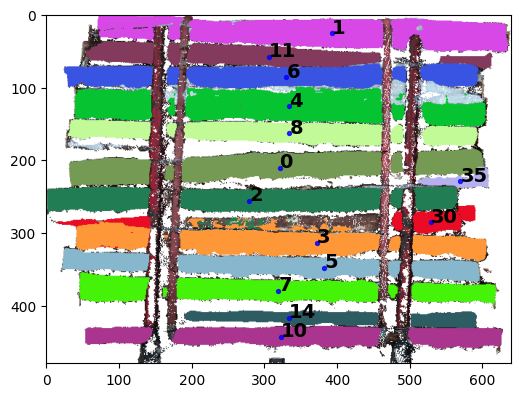

Length of log 0 is 2.6443744657696797
Length of log 1 is 2.5055112049164787
Length of log 2 is 2.779940602220763
Length of log 3 is 2.603260542457969
Length of log 4 is 2.610831539495198
Length of log 5 is 2.688665555309406
Length of log 6 is 2.6766208997124066
Length of log 7 is 2.583072297227071
Length of log 8 is 2.652460494931197
Length of log 10 is 2.547755058848769
Length of log 11 is 2.557796608722704
Length of log 14 is 1.940404148988724
Length of log 30 is 2.7196483426641356
Length of log 35 is 0.5063857276882525


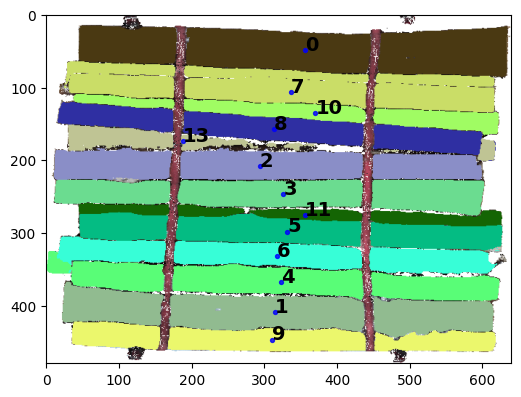

Length of log 0 is 2.5453414093650943
Length of log 1 is 2.5846166068289826
Length of log 2 is 2.629249516770111
Length of log 3 is 2.6291785182097827
Length of log 4 is 2.6891605170036517
Length of log 5 is 2.5109861697832176
Length of log 6 is 2.6713659542634116
Length of log 7 is 2.5875338590377233
Length of log 8 is 2.6099833933182075
Length of log 9 is 2.5220135979876055
Length of log 10 is 2.524791280937511
Length of log 11 is 2.5133530330296074
Length of log 13 is 2.5483205801829105
{'width_median': np.float64(2.332224277678028), 'width_mad': np.float64(0.0018955313855277822), 'width_mean': np.float64(2.3317773920144074), 'width_count': 9, 'width_min': np.float64(2.3247662923296897), 'width_max': np.float64(2.335173446371143), 'height_median': np.float64(2.4611875832564465), 'height_mad': np.float64(0.006971676635925128), 'height_mean': np.float64(2.4629474566773473), 'height_count': 9, 'height_min': np.float64(2.4523575180256163), 'height_max': np.float64(2.476903392554497), 'a

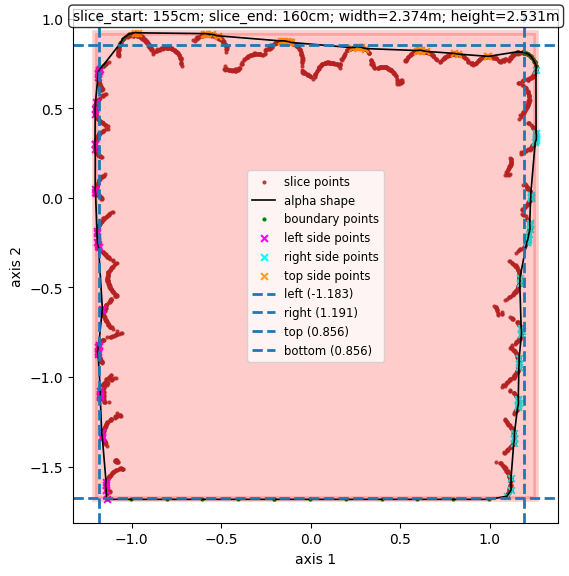

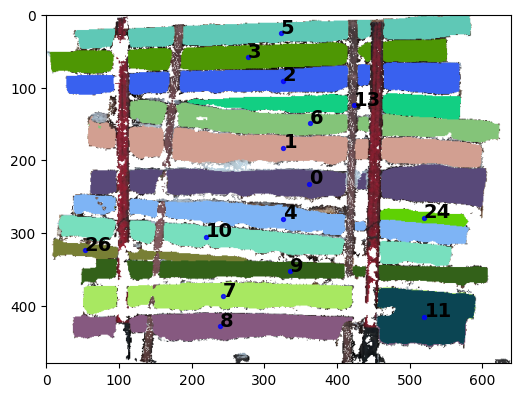

Length of log 0 is 2.533911850813812
Length of log 1 is 2.5215525753825054
Length of log 2 is 2.521857353909152
Length of log 3 is 2.5452702197922568
Length of log 4 is 2.6168187478242944
Length of log 5 is 2.532424291696217
Length of log 6 is 2.6295044920535955
Length of log 7 is 2.5116136684299266
Length of log 8 is 2.519996720623759
Length of log 9 is 2.604166637856915
Length of log 10 is 2.516892369514073
Length of log 11 is 0.6269681227342123
Length of log 13 is 1.7505370743311177
Length of log 24 is 0.5565821026235449
Length of log 26 is 2.5239470575690532


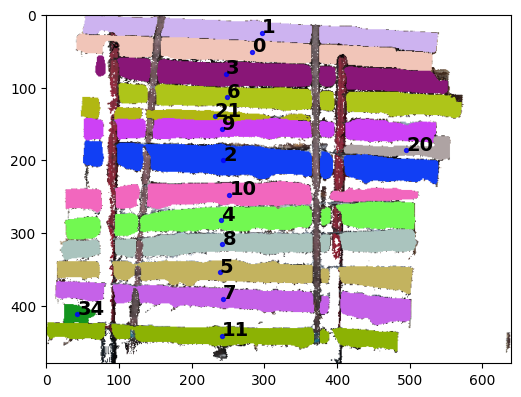

Length of log 0 is 2.535597452940564
Length of log 1 is 2.526000623519809
Length of log 2 is 2.530331409800126
Length of log 3 is 2.5101805763810763
Length of log 4 is 2.491308865027656
Length of log 5 is 2.530253978369656
Length of log 6 is 2.4431265974719425
Length of log 7 is 2.5309457649185902
Length of log 8 is 2.5303515389336595
Length of log 9 is 2.510275130182074
Length of log 10 is 2.5106774701829266
Length of log 11 is 2.5031947841911864
Length of log 20 is 0.8781804509702438
Length of log 21 is 1.7521919921128437
Length of log 34 is 1.874342729261299


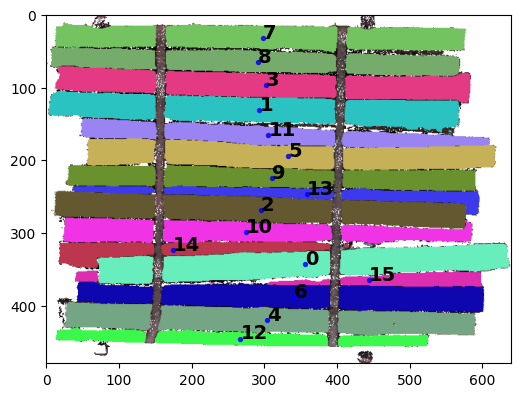

Length of log 0 is 2.6643647434543256
Length of log 1 is 2.5212980660587165
Length of log 2 is 2.5263543971466094
Length of log 3 is 2.545843698725447
Length of log 4 is 2.5204983249399477
Length of log 5 is 2.505300551452403
Length of log 6 is 2.49542514389621
Length of log 7 is 2.514757983234653
Length of log 8 is 2.507586233692515
Length of log 9 is 2.50907177495975
Length of log 10 is 2.5129728026812117
Length of log 11 is 2.5082060412525697
Length of log 12 is 2.283714170950093
Length of log 13 is 2.4928391755550408
Length of log 14 is 1.77932873325906
Length of log 15 is 2.4990758406450952
{'width_median': np.float64(2.362504763798302), 'width_mad': np.float64(0.003188401482371095), 'width_mean': np.float64(2.3622619486450818), 'width_count': 9, 'width_min': np.float64(2.351635293420494), 'width_max': np.float64(2.3742881934510622), 'height_median': np.float64(2.518421207979012), 'height_mad': np.float64(0.0058843062221378695), 'height_mean': np.float64(2.51937586298478), 'height

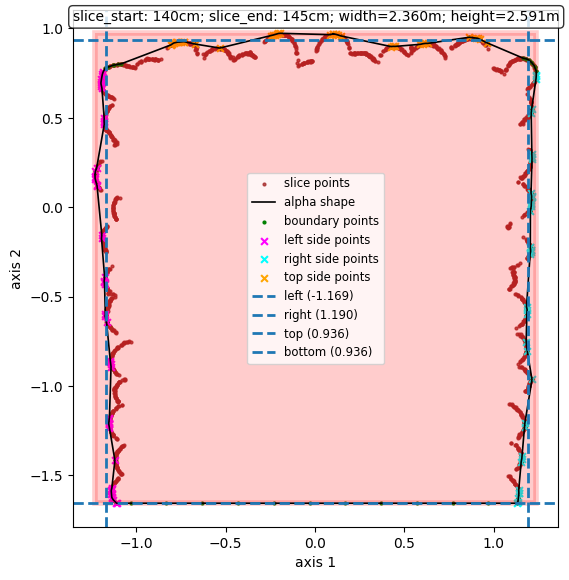

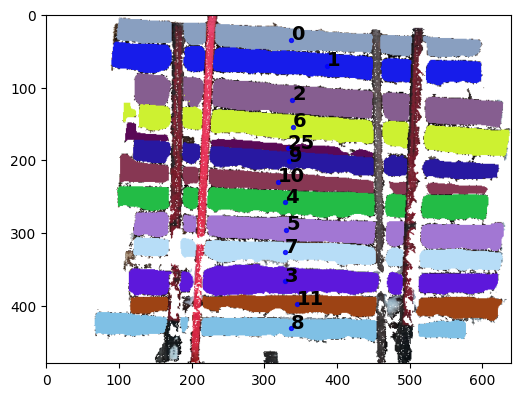

Length of log 0 is 2.4932260978469003
Length of log 1 is 2.531284691278139
Length of log 2 is 2.517941394063234
Length of log 3 is 2.5220187559426845
Length of log 4 is 2.5327461348247535
Length of log 5 is 2.5310369112292497
Length of log 6 is 2.642999114101186
Length of log 7 is 2.5213338309776674
Length of log 8 is 2.6008496816485502
Length of log 9 is 2.498692886927997
Length of log 10 is 2.5122239309892374
Length of log 11 is 2.5428181975828554
Length of log 25 is 2.3921938372658955


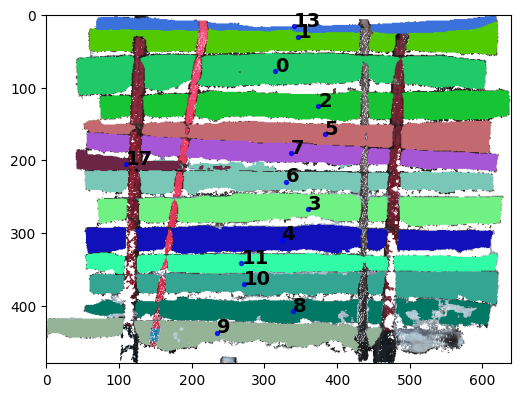

Length of log 0 is 2.531416352149277
Length of log 1 is 2.5160983109889195
Length of log 2 is 2.5251359373917905
Length of log 3 is 2.492480633645264
Length of log 4 is 2.505283296748207
Length of log 5 is 2.507163231472475
Length of log 6 is 2.5961598958480367
Length of log 7 is 2.5902439898984477
Length of log 8 is 2.500683754100786
Length of log 9 is 2.711385416464455
Length of log 10 is 2.515046640366694
Length of log 11 is 2.533135331297361
Length of log 13 is 2.4654221823165736
Length of log 17 is 2.53576201459349


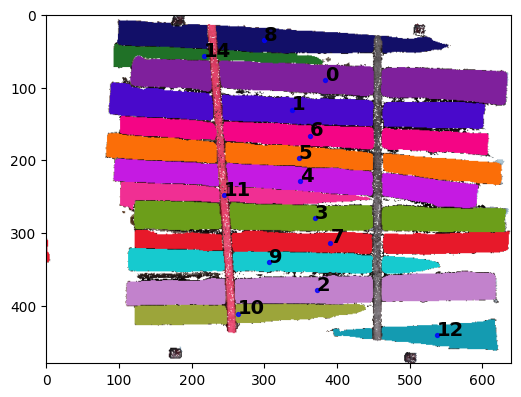

Length of log 0 is 2.5644112877367187
Length of log 1 is 2.5573370130035036
Length of log 2 is 2.518209322760331
Length of log 3 is 2.534174135146606
Length of log 4 is 2.484583824904738
Length of log 5 is 2.6903483501574303
Length of log 6 is 2.507723481159317
Length of log 7 is 3.155225523351021
Length of log 8 is 2.362469537041858
Length of log 9 is 2.290632030119344
Length of log 10 is 2.2450278030147555
Length of log 11 is 2.3438898249197457
Length of log 12 is 1.1202018389923527
Length of log 14 is 2.390006629222886
{'width_median': np.float64(2.3643741219562515), 'width_mad': np.float64(0.004861230429869412), 'width_mean': np.float64(2.3660603253171613), 'width_count': 9, 'width_min': np.float64(2.3582306447364125), 'width_max': np.float64(2.3756018805348553), 'height_median': np.float64(2.591331055433823), 'height_mad': np.float64(0.008669902490225478), 'height_mean': np.float64(2.5927688500874764), 'height_count': 9, 'height_min': np.float64(2.5803065557178555), 'height_max': 

In [321]:
export_point_cloud("DATA/pcd_results.las", exported_pc, colors)

In [7]:
rot_pts = pca_3_components(point_cloud)

In [132]:
mins = np.min(rot_pts, axis=0)
maxs = np.max(rot_pts, axis=0)

# cabin is usually around 3 meters
xpoints_to_consider = np.arange(maxs[0]-1, mins[0]+3, -4)
y_top = np.repeat(maxs[1]+3, len(xpoints_to_consider))
y_bot = np.repeat(mins[1]-3, len(xpoints_to_consider))
y_mid = np.repeat(maxs[1]+5, len(xpoints_to_consider))
z_mid = np.repeat(np.mean([maxs[2], mins[2]]), len(xpoints_to_consider))
z_top = np.repeat(maxs[2]+10, len(xpoints_to_consider))
perspective_points = np.array([*zip(xpoints_to_consider, y_top, z_mid), *zip(xpoints_to_consider, y_bot, z_mid)])
perspective_points

array([[ 6.57676225,  4.44118253, -0.46830523],
       [ 2.57676225,  4.44118253, -0.46830523],
       [-1.42323775,  4.44118253, -0.46830523],
       [-5.42323775,  4.44118253, -0.46830523],
       [ 6.57676225, -4.38056937, -0.46830523],
       [ 2.57676225, -4.38056937, -0.46830523],
       [-1.42323775, -4.38056937, -0.46830523],
       [-5.42323775, -4.38056937, -0.46830523]])

In [644]:
np.min(rot_pts, axis=0)

array([-8.81235614, -1.38056937, -2.50915523])

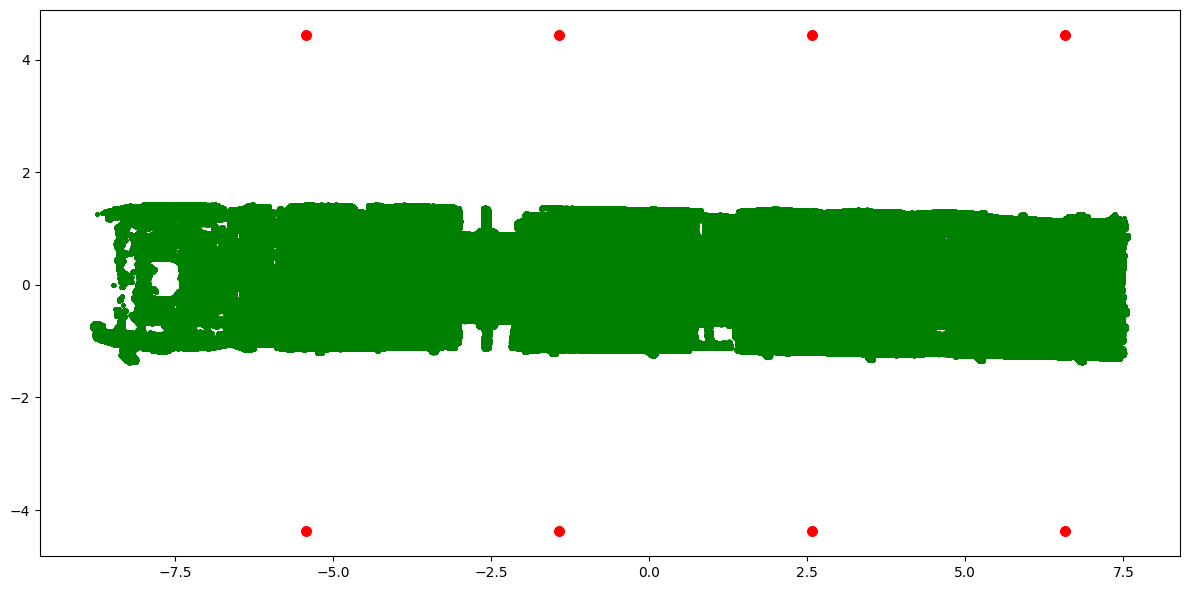

In [133]:
fig, ax = plt.subplots(figsize=(12,6))
ax.scatter(rot_pts[:,0], rot_pts[:,1], s=4, label='rot points', c='green')
ax.scatter(perspective_points[:, 0], perspective_points[:, 1], s=48, c='red')
plt.tight_layout()
plt.show()
plt.close()

In [162]:
pim = Image.open("DATA/testlog.png")
inference_state = processor.set_image(pim)
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="horizontal timber logs")
img_np = np.array(pim).astype(np.uint8) 
print(img_np.shape)
print(inference_state['masks'].shape)
# img_np = build_mask_img(img_np, inference_state)
# plot_results(pim, inference_state)



(480, 640, 3)
torch.Size([38, 1, 480, 640])


In [48]:
import numpy as np

def columnwise_above_below(mask1, mask2):
    H, W = mask1.shape
    # initialize with +inf / -inf
    top1 = np.full(W, np.inf)
    bottom1 = np.full(W, -np.inf)
    top2 = np.full(W, np.inf)
    bottom2 = np.full(W, -np.inf)

    # indices
    r1, c1 = np.where(mask1)
    r2, c2 = np.where(mask2)

    # fill top/bottom per column
    # top = min row index, bottom = max row index
    np.minimum.at(top1, c1, r1)
    np.maximum.at(bottom1, c1, r1)
    np.minimum.at(top2, c2, r2)
    np.maximum.at(bottom2, c2, r2)

    # columns where both masks have pixels
    common_cols = np.where((bottom1 >= 0) & (bottom2 >= 0))[0]

    # check if mask1 has any pixel above mask2 in same column:
    # mask1 is above mask2 in a column if bottom1 < top2 (entire mask1 segment above mask2)
    mask1_above_cols = common_cols[ bottom1[common_cols] < top2[common_cols] ]

    # check if mask1 has any pixel below mask2 in same column:
    mask1_below_cols = common_cols[ top1[common_cols] > bottom2[common_cols] ]

    return mask1_above_cols.size > 0 or mask1_below_cols.size > 0

# Example usage:
# result = columnwise_above_below(mask1, mask2)
# print(result["any_above"], result["any_below"])

import numpy as np
from skimage import measure
from typing import Tuple, Optional, List, Dict


def first_pca_vector(coords: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    coords: Nx2 array of (x, y) points.
    Returns: centroid (2,), pc1 (unit vector, 2,)
    Uses SVD (no extra dependencies).
    """
    if coords.shape[0] < 2:
        raise ValueError("Need at least 2 points for PCA")
    centroid = coords.mean(axis=0)
    centered = coords - centroid
    # SVD on centered coordinates
    U, S, Vt = np.linalg.svd(centered, full_matrices=False)
    pc1 = Vt[0]  # first principal direction (unit)
    # ensure consistent orientation (optional): we won't force sign, both directions are used
    return centroid, pc1

def sample_along_ray(label_img: np.ndarray,
                     origin_xy: np.ndarray,
                     direction_xy: np.ndarray,
                     target_label: int,
                     max_dist: float = 500.0,
                     step: float = 1.0,
                     search_radius: int = 0) -> Optional[Dict]:
    """
    Walk from origin in `direction_xy` (unit vector) and return the first encountered label
    different from target_label and background (0). Returns a dict with:
      { 'label': found_label, 'distance': dist_pixels, 'point_xy': (x,y) }
    If none found within max_dist, returns None.

    search_radius: integer radius (in pixels) to check around each sample point (useful to catch thin masks).
    """
    H, W = label_img.shape
    n_steps = int(np.ceil(max_dist / step))
    dir_vec = np.array(direction_xy, dtype=float)
    norm = np.linalg.norm(dir_vec)
    if norm == 0:
        raise ValueError("direction vector has zero length")
    dir_vec = dir_vec / norm

    for i in range(1, n_steps + 1):
        dist = i * step
        sample_xy = origin_xy + dir_vec * dist  # float coords (x,y)
        sx, sy = int(round(sample_xy[0])), int(round(sample_xy[1]))  # nearest pixel
        # check bounds
        if sx < 0 or sx >= W or sy < 0 or sy >= H:
            # out of image - stop searching in this direction
            break

        # optionally check a small neighborhood
        if search_radius <= 0:
            lbl = label_img[sy, sx]
            if lbl != 0 and lbl != target_label:
                return {'label': int(lbl), 'distance': float(dist), 'point_xy': (float(sample_xy[0]), float(sample_xy[1]))}
        else:
            # neighborhood coordinates
            y0 = max(0, sy - search_radius)
            y1 = min(H, sy + search_radius + 1)
            x0 = max(0, sx - search_radius)
            x1 = min(W, sx + search_radius + 1)
            sub = label_img[y0:y1, x0:x1]
            # find any label that's not 0 or target_label
            unique = np.unique(sub)
            for u in unique:
                if u != 0 and u != target_label:
                    return {'label': int(u), 'distance': float(dist), 'point_xy': (float(sample_xy[0]), float(sample_xy[1]))}
    return None

def find_neighbors_along_pc(label_img: np.ndarray,
                            target_label: int,
                            max_dist: float = 500.0,
                            step: float = 1.0,
                            search_radius: int = 0) -> Dict[str, Optional[Dict]]:
    """
    Main function: computes centroid + PC1 for target_label, then searches on both sides.
    Returns dict: {'centroid':(x,y), 'pc1':(x,y), 'left':result_or_None, 'right':result_or_None}
    """
    # optionally relabel if input is boolean mask:
    if label_img.dtype == bool or label_img.max() == 1:
        # convert boolean mask for single object (but user should pass labeled image)
        raise ValueError("label_img appears boolean or binary. Provide a labeled image where each object has unique integer labels.")
    # get coordinates of target label: (x,y) points
    ys, xs = np.where(label_img == target_label)
    if ys.size == 0:
        raise ValueError("target_label not found in label_img")
    coords_xy = np.column_stack((xs, ys)).astype(float)  # (x,y)

    centroid, pc1 = first_pca_vector(coords_xy)

    # search right (+pc1) and left (-pc1)
    right_hit = sample_along_ray(label_img, centroid, +pc1, target_label, max_dist, step, search_radius)
    left_hit  = sample_along_ray(label_img, centroid, -pc1, target_label, max_dist, step, search_radius)

    return {
        'centroid': (float(centroid[0]), float(centroid[1])),
        'pc1': (float(pc1[0]), float(pc1[1])),
        'right': right_hit,
        'left': left_hit
    }

# ------------------------
# Example usage:
# ------------------------
# Suppose `label_img` is your 2D array with integer labels, and we want to inspect label 3:
# res = find_neighbors_along_pc(label_img, target_label=3, max_dist=300, step=1.0, search_radius=1)
# print(res)

In [100]:
inference_state['scores']

tensor([0.7595, 0.5892, 0.6430, 0.6533, 0.7685, 0.7864, 0.7423, 0.8004, 0.7511,
        0.6823, 0.6319, 0.7501, 0.8306, 0.8165, 0.7541, 0.5258, 0.7723, 0.8844,
        0.7539, 0.6746, 0.8364, 0.7787, 0.7045, 0.6705, 0.5950, 0.6735, 0.8021,
        0.7347, 0.8197, 0.6865, 0.5701, 0.7908, 0.5160, 0.8391, 0.6860, 0.7547,
        0.8453, 0.6059], device='cuda:0')

In [ ]:
masks = inference_state['masks']
np_masks = masks.permute(1,0,2,3).squeeze().detach().cpu().numpy()
sorted_masks = sorted(np_masks, key=lambda x: len(x[x]), reverse=True)
mask_objs = [{"id": i, "mask":m} for i,m in enumerate(sorted_masks)]

for mask_obj in mask_objs:
    mask = mask_obj['mask']
    print(mask_obj['id'])
    ys, xs = np.where(mask)
    coords_xy = np.column_stack((xs, ys)).astype(float)  # (x,y)
    centroid = coords_xy.mean(axis=0)
    centered = coords_xy - centroid
    # SVD on centered coordinates
    U, S, Vt = np.linalg.svd(centered, full_matrices=False)
    pc1 = Vt[0]
    pc1 = pc1 / np.linalg.norm(pc1)
    candidates = [c for c in mask_objs if c['id'] != mask_obj['id']]
    valid_cand = []
    for c in candidates:
        c_mask = c['mask']
        not_cand = columnwise_above_below(mask, c_mask)
        # print(f'Mask #{mask_obj["id"]}; Cand: #{c["id"]}: {not_cand}')
        if (not not_cand):
            valid_cand.append(c)
    # print([c['id'] for c in valid_cand])
    label_img = np.ones_like(mask, dtype=np.int32)*-1
    for c in valid_cand:
        label_img[c['mask']] = c['id']
    label_img[mask] = mask_obj['id']

    print(np.unique(label_img))
    projections = centered.dot(pc1)  # shape (n,)
    min_proj = projections.min()
    max_proj = projections.max()
    endpoint_left = centroid + pc1 * min_proj   # corresponds to min (left/backwards)
    endpoint_right = centroid + pc1 * max_proj  # corresponds to max (right/forward)
    W,H = mask.shape
    def march_ray(dir_vec: np.ndarray, start_xy: np.ndarray) -> Optional[List[Dict]]:
        """
        March from start_xy + step*dir_vec outwards, checking label_img at each sampled pixel.
        Returns first hit dict or (if collect_all True) list of hits in order.
        """
        hits = []
        n_steps = int(np.ceil(mask.shape[0] ))
        for i in range(1, n_steps + 1):
            dist_from_endpoint = i
            point_xy = start_xy + dir_vec * dist_from_endpoint
            sx = int(round(point_xy[0])); sy = int(round(point_xy[1]))  # col=x -> sx, row=y -> sy
            # bounds check
            if sx < 0 or sx >= W or sy < 0 or sy >= H:
                break
            found_label = None
            lbl = int(label_img[sy, sx])
            if lbl != -1 and lbl != mask_obj['id']:
                found_label = lbl
                for i, o in enumerate(mask_objs):
                    if o["id"] == lbl:
                        mask_objs.pop(i)

            if found_label is not None:
                hit = {
                    'label': int(found_label) - 1,  # return original mask index
                    'distance_from_centroid': float(( (start_xy + dir_vec * dist_from_endpoint - centroid).dot(dir_vec) )),
                    'distance_from_endpoint': float(dist_from_endpoint),
                    'point_xy': (float(point_xy[0]), float(point_xy[1]))
                }
                hits.append(hit)
            return hits
        return []

    # Right: march along +pc1 starting from endpoint_right
    right_hits = march_ray(pc1, endpoint_right)
    # Left: march along -pc1 starting from endpoint_left
    left_hits = march_ray(-pc1, endpoint_left)

    # collapse single-item lists if not collecting all
    def first_or_none(h):
        return h

    result = {
        'centroid': (float(centroid[0]), float(centroid[1])),
        'pc1': (float(pc1[0]), float(pc1[1])),
        'endpoint_left': (float(endpoint_left[0]), float(endpoint_left[1])),
        'endpoint_right': (float(endpoint_right[0]), float(endpoint_right[1])),
        'left': first_or_none(left_hits),
        'right': first_or_none(right_hits)
    }

    for i, o in enumerate(mask_objs):
        if o["id"] == mask:
            mask_objs.pop(i)

    print(result)
    print()

0
[-1  0]
{'centroid': (314.99585187419865, 43.886039671166756), 'pc1': (0.9993650275168436, 0.03563062974827508), 'endpoint_left': (103.55976584298566, 36.347652105692724), 'endpoint_right': (525.3427849504975, 51.385595373800626), 'left': [], 'right': []}

2
[-1  2 11 24 31 32 33 34 35 37]
{'centroid': (295.52162409687594, 102.28085885824768), 'pc1': (0.999925709732176, 0.012189135186890139), 'endpoint_left': (94.8679223458793, 99.83488204958265), 'endpoint_right': (488.11423810567317, 104.62857067853737), 'left': [{'label': 23, 'distance_from_centroid': 201.66860947573852, 'distance_from_endpoint': 1.0, 'point_xy': (93.86799663614711, 99.82269291439576)}], 'right': []}

4
[-1  4 15 26 33 35 37]
{'centroid': (290.79325084364456, 161.92958380202475), 'pc1': (0.9998452126660679, 0.017594053221064273), 'endpoint_left': (104.7948811987795, 158.65661197287835), 'endpoint_right': (525.1046531482182, 166.0527092920757), 'left': [], 'right': []}

6
[-1  6 18 31 32 33 34 35 37]
{'centroid': (

In [98]:
def mask_iou(mask_a, mask_b):
    # boolean numpy arrays same shape
    inter = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a, mask_b).sum()
    return 0.0 if union == 0 else inter / union

def mask_nms(masks, scores, iou_thresh=0.5):
    # masks: list/array of boolean arrays, scores: numpy array (N,)
    order = np.argsort(scores)[::-1]
    keep = []
    while order.size:
        i = order[0]
        keep.append(i)
        if order.size == 1:
            break
        rest = order[1:]
        ious = np.array([mask_iou(masks[i], masks[j]) for j in rest])
        order = rest[ious <= iou_thresh]
    return np.array(keep, dtype=int)

In [103]:
len(np_masks)

38

In [124]:
masks = inference_state['masks']
np_masks = masks.permute(1,0,2,3).squeeze().detach().cpu().numpy()
to_keep = mask_nms(np_masks, inference_state['scores'].detach().cpu().numpy(), 0.2)
sorted_masks = sorted(np_masks[to_keep], key=lambda x: len(x[x]), reverse=True)



0
1
2
3
4
5
6
7
8
9
10
11
13


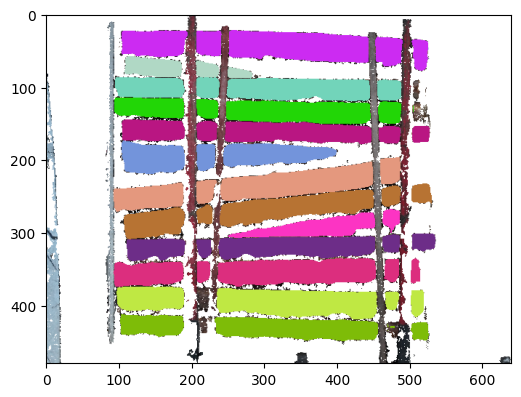

In [126]:
masks = inference_state['masks']
np_masks = masks.permute(1,0,2,3).squeeze().detach().cpu().numpy()
to_keep = mask_nms(np_masks, inference_state['scores'].detach().cpu().numpy(), 0.2)
sorted_masks = sorted(np_masks[to_keep], key=lambda x: len(x[x]), reverse=True)

grouped_labels = []
groups=[]
fig, ax = plt.subplots(figsize=(6,6))


for mask_id in range(len(sorted_masks)):
    if mask_id in grouped_labels:
        continue
    group = [mask_id]
    grouped_labels.append(mask_id)
    analysed_mask = sorted_masks[mask_id]
    H,W = analysed_mask.shape
    ys, xs = np.where(analysed_mask)
    coords_xy = np.column_stack((xs, ys)).astype(float)  # (x,y)
    centroid = coords_xy.mean(axis=0)
    centered = coords_xy - centroid
    U, S, Vt = np.linalg.svd(centered, full_matrices=False)
    pc1 = Vt[0]
    vx, vy = float(pc1[0]), float(pc1[1])
    angle_rad = np.arctan2(vy, vx)
    angle_deg = np.degrees(angle_rad)
    pc1 = pc1 / np.linalg.norm(pc1)
    projections = centered.dot(pc1)
    min_proj = projections.min()
    max_proj = projections.max()
    endpoint_left = centroid + pc1 * min_proj
    endpoint_right = centroid + pc1 * max_proj

    print(mask_id)
    line_pts= []
    analysis_img = np.ones_like(analysed_mask, dtype=np.int32)*-1
    for c_mask_id in range(len(sorted_masks)):
        if c_mask_id in grouped_labels:
            continue
        c_mask = sorted_masks[c_mask_id]
        analysis_img[c_mask] = c_mask_id

    def march_ray(dir_vec, start_xy):
        n_steps = int(2000)
        for i in range(1, n_steps + 1):
            dist_from_endpoint = i
            point_xy = start_xy + dir_vec * dist_from_endpoint
            sx = int(round(point_xy[0])); sy = int(round(point_xy[1]))
            if sx < 0 or sx >= W or sy < 0 or sy >= H:
                break
            found_label = None
            line_pts.append(np.array([sy,sx]))
            lbl = int(analysis_img[sy, sx])
            if lbl != -1 and lbl != mask_obj['id'] and lbl not in grouped_labels and lbl not in group:
                found_label = lbl
                grouped_labels.append(found_label)
                group.append(found_label)

    march_ray(pc1, endpoint_right)
    march_ray(-pc1, endpoint_left)
    # groups.append(group)
    merged_mask = np.zeros_like(img_np)
    # print(group)
    for g_mask_id in group:
        g_mask = sorted_masks[g_mask_id]
        merged_mask[g_mask] = 1
    merged_mask = merged_mask.astype(bool)
    g_color = np.random.randint(0, 256, size=3)
    fg = np.broadcast_to(g_color, img_np.shape).astype(np.uint8)
    img_np[merged_mask] = fg[merged_mask]
    line_ptsa=np.array(line_pts)
    # if len(line_ptsa) >0 :
        # ax.scatter(line_ptsa[:,1], line_ptsa[:,0], s=1, alpha=0.8, label='slice points', c='blue')
        # ax.scatter(centroid[0], centroid[1], s=8, alpha=0.8, label='slice points', c='blue')
plt.imshow(img_np)


In [ ]:
# points = random_side_points_from_pca(
#         rot_pts,
#         n=20,
#         offset_m=3.0,
#         side='both',
#         project_to_xy=True,
#         sample_by_density=False
#     )
exported_pc = collect_points(perspective_points, rot_pts, 700)


In [120]:
point_cloud

array([[23.0999, 58.5123, 73.4335],
       [23.0767, 58.4549, 73.4034],
       [23.0647, 58.4338, 73.4013],
       ...,
       [28.677 , 43.3595, 76.6339],
       [28.7512, 43.3314, 76.587 ],
       [28.7341, 43.3304, 76.6077]], shape=(9529515, 3))

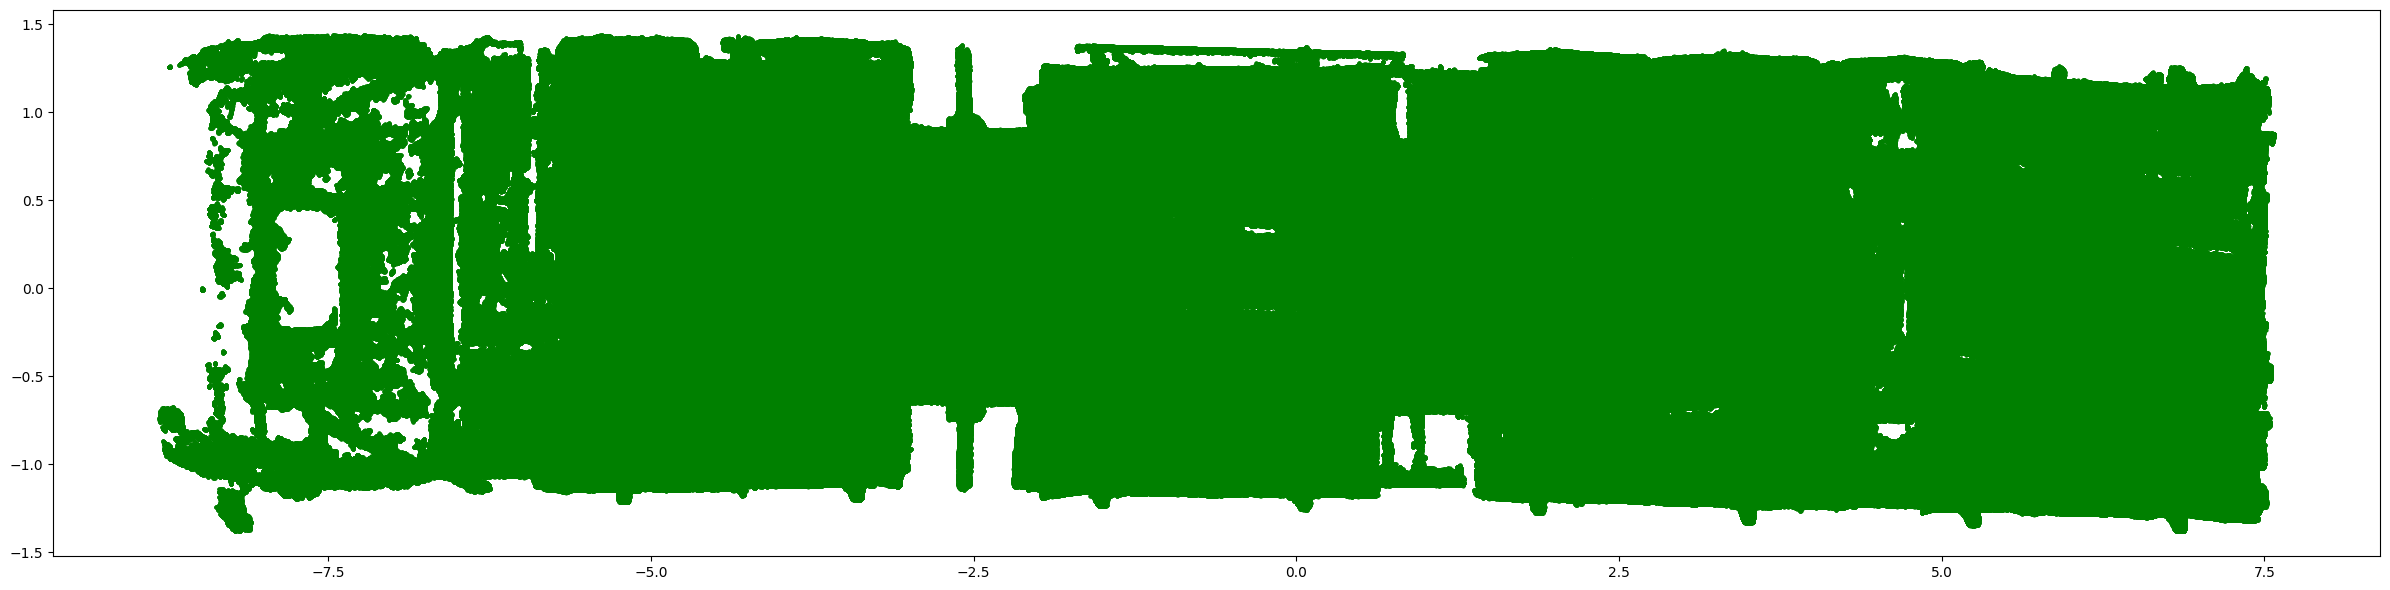

In [22]:
fig, ax = plt.subplots(figsize=(24,6))
ax.scatter(exported_pc[:,0], exported_pc[:,1], s=4, label='rot points', c='green')
# ax.scatter(perspective_points[:, 0], perspective_points[:, 1], s=48, c='red')
plt.tight_layout()
plt.show()
plt.close()

In [230]:
masks = inference_state['masks'].detach().cpu().numpy()
masks[0][0]

# 1. identify shapely poly
# 2. find pca
# 3. take only horizontalish pca (with the highest projection to x axis value)
# 4. 


array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(480, 640))

In [192]:
inference_state

{'original_height': 480,
 'original_width': 640,
 'backbone_out': {'vision_features': tensor([[[[-0.1882,  0.1059, -0.0184,  ..., -0.3816, -0.1947, -0.4207],
            [-0.0339, -0.5149, -0.1980,  ..., -0.5707, -0.7381, -0.2976],
            [-0.2979, -0.1405, -0.0237,  ..., -0.2233, -1.1098, -0.5929],
            ...,
            [ 0.5620, -0.5946, -0.8895,  ..., -0.3747, -0.1959, -0.4140],
            [-0.2289, -0.3471, -0.7789,  ..., -0.3270, -0.4548, -1.1876],
            [-0.9290, -0.6788, -0.6647,  ...,  0.0235,  0.0613, -1.0268]],
  
           [[-0.1822, -0.2426, -0.2705,  ..., -0.3164, -0.4044, -0.0275],
            [-0.3810,  0.5151,  0.4899,  ...,  0.5087,  0.1792, -0.0450],
            [-0.6095,  0.5088,  0.9053,  ...,  0.3760,  0.5848, -0.0790],
            ...,
            [-0.8025,  0.0912,  0.2507,  ..., -0.3113, -0.0952, -0.4796],
            [-1.0984,  0.4323,  0.2920,  ..., -0.0597, -0.2395, -0.2890],
            [-0.1816,  0.8477,  0.6398,  ...,  0.5097, -0.0136, 

Processing pile #1


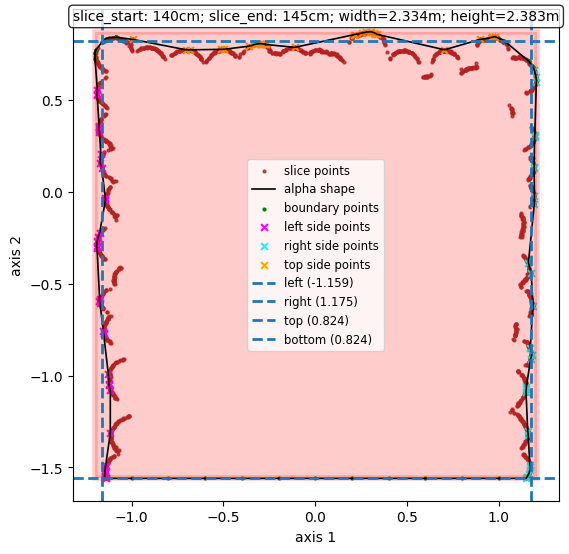

test
zero-size array to reduction operation minimum which has no identity
Processing pile #2


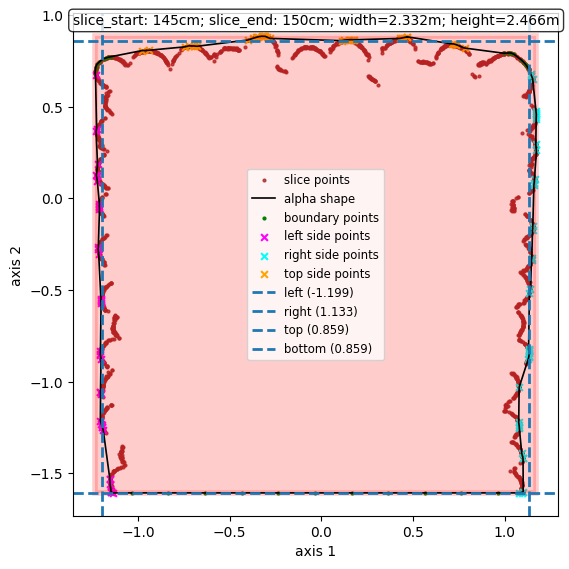

test
zero-size array to reduction operation minimum which has no identity
Processing pile #3


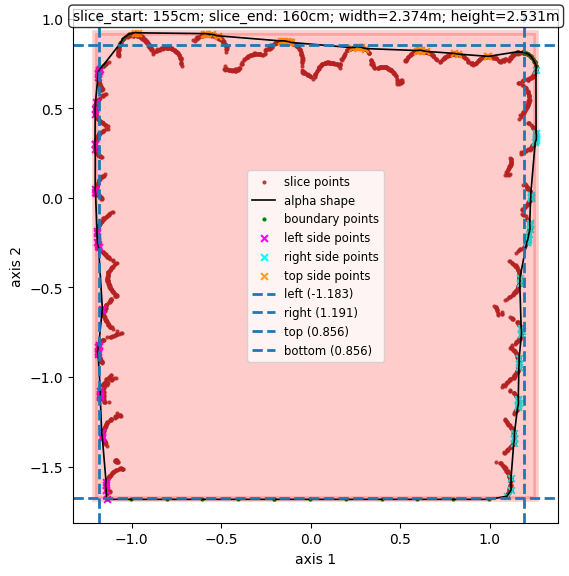

test
zero-size array to reduction operation minimum which has no identity
Processing pile #4


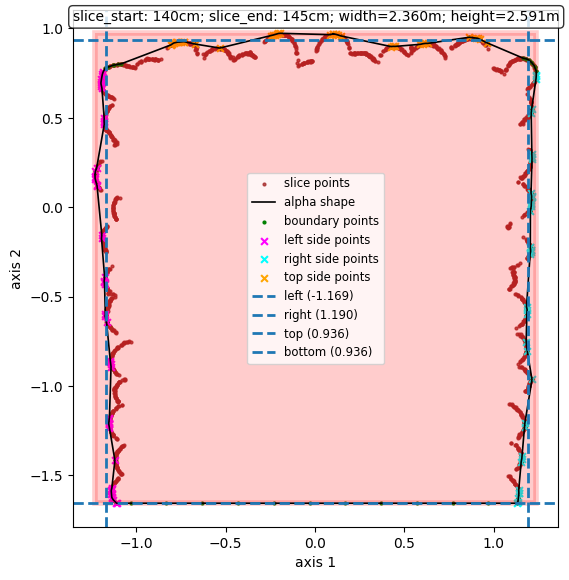

test
zero-size array to reduction operation minimum which has no identity
   width_median  width_mad  width_mean  width_count  width_min  width_max  \
0      2.334416   0.002690    2.333910            9   2.325543   2.341147   
1      2.332224   0.001896    2.331777            9   2.324766   2.335173   
2      2.362505   0.003188    2.362262            9   2.351635   2.374288   
3      2.364374   0.004861    2.366060            9   2.358231   2.375602   

   height_median  height_mad  height_mean  height_count  height_min  \
0       2.383251    0.009046     2.387404             9    2.374205   
1       2.461188    0.006972     2.462947             9    2.452358   
2       2.518421    0.005884     2.519376             9    2.509062   
3       2.591331    0.008670     2.592769             9    2.580307   

   height_max  
0    2.401957  
1    2.476903  
2    2.530795  
3    2.608625  
Wrote 442775 points to DATA/pcd_results.las


In [141]:
export_point_cloud("DATA/pcd_results.las", exported_pc, colors)

In [ ]:
rot_pts

array([[-8.53555678,  1.3024874 , -1.98575523],
       [-8.48437127,  1.33731618, -2.01585523],
       [-8.46629087,  1.35351213, -2.01795523],
       ...,
       [ 7.45460531, -0.93941101,  1.21464477],
       [ 7.4977805 , -1.00597792,  1.16774477],
       [ 7.49513676, -0.98905395,  1.18844477]], shape=(9529515, 3))

done clustering
Polygon5((1.58127, 1.2323) ...)


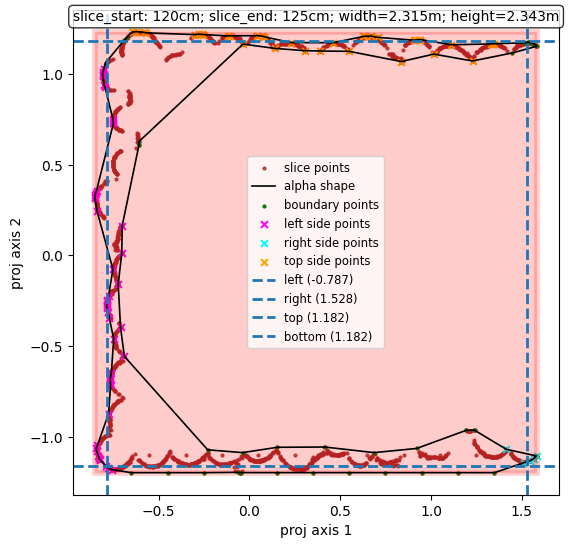

Polygon5((1.59502, -1.20197) ...)


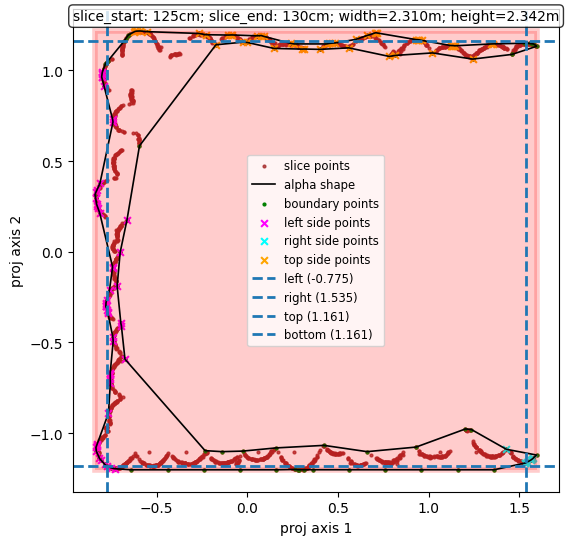

error arrays used as indices must be of integer (or boolean) type
Polygon5((1.57627, -1.17257) ...)


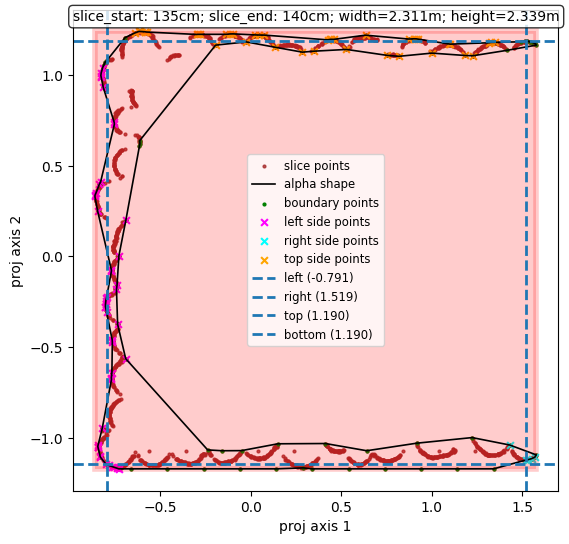

Polygon5((1.55973, 1.2054) ...)


KeyboardInterrupt: 

In [968]:
export_point_cloud("DATA/pcd_results.las", exported_pc)

In [ ]:
model = build_sam3_image_model(checkpoint_path='MODELS/sam3.pt')
processor = Sam3Processor(model, confidence_threshold=0.5)


In [ ]:
image_path = f"DATA/test_spherical_projection.jpg"
image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold=0.5)
inference_state = processor.set_image(image)


In [172]:
from sklearn.cluster import KMeans
from matplotlib.colors import to_rgb
from skimage.color import lab2rgb, rgb2lab
def generate_colors(n_colors=256, n_samples=5000):
    # Step 1: Random RGB samples
    np.random.seed(42)
    rgb = np.random.rand(n_samples, 3)
    # Step 2: Convert to LAB for perceptual uniformity
    # print(f"Converting {n_samples} RGB samples to LAB color space...")
    lab = rgb2lab(rgb.reshape(1, -1, 3)).reshape(-1, 3)
    # print("Conversion to LAB complete.")
    # Step 3: k-means clustering in LAB
    kmeans = KMeans(n_clusters=n_colors, n_init=10)
    # print(f"Fitting KMeans with {n_colors} clusters on {n_samples} samples...")
    kmeans.fit(lab)
    # print("KMeans fitting complete.")
    centers_lab = kmeans.cluster_centers_
    # Step 4: Convert LAB back to RGB
    colors_rgb = lab2rgb(centers_lab.reshape(1, -1, 3)).reshape(-1, 3)
    colors_rgb = np.clip(colors_rgb, 0, 1)
    return colors_rgb


COLORS = generate_colors(n_colors=128, n_samples=5000)

In [157]:
img0 = Image.open(image_path)
img0.size

(1000, 500)

found 5 object(s)
[0.91811674 0.15919377 0.11266725]
[234  40  28]
[0.24262193 0.4811227  0.63009073]
[ 61 122 160]
[0.68013952 0.82431992 0.17740459]
[173 210  45]
[0.49107573 0.1246308  0.64543147]
[125  31 164]
[0.69871046 0.5937359  0.35462178]
[178 151  90]


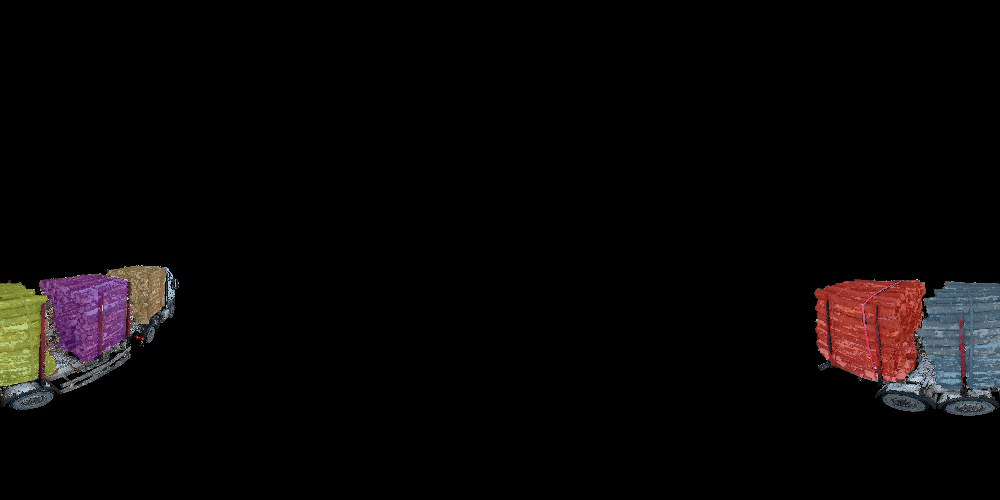

In [ ]:
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="pile")

img0 = Image.open(image_path)
img_np = np.array(img0)
# print(inference_state)
# plot_results(img0, inference_state)


def mask_to_bool(mask):
    """Accepts torch tensor or numpy array, squeezes channel dim, returns bool HxW"""
    # If mask is torch tensor, convert:
    try:
        import torch
        if isinstance(mask, torch.Tensor):
            mask = mask.detach().cpu().numpy()
    except Exception:
        pass
    mask = np.asarray(mask)
    # typical shape possibilities: (1,H,W), (H,W), (H,W,1)
    if mask.ndim == 3 and mask.shape[0] == 1:
        mask = mask[0]
    if mask.ndim == 3 and mask.shape[2] == 1:
        mask = mask[...,0]
    return mask.astype(bool)

nb_objects = len(inference_state["scores"])
if isinstance(image_path, str):
    img = Image.open(image_path).convert("RGB")
else:
    img = image_path.convert("RGB")
img_np = np.array(img).astype(np.uint8)  # H x W x 3

masks = inference_state["masks"]
# if masks is a torch tensor shaped (N,1,H,W) or (N,H,W), handle below
# ensure masks is indexable
nb_objects = len(inference_state.get("scores", masks))
print(f"found {nb_objects} object(s)")

H, W = img_np.shape[:2]

for i in range(nb_objects):
    color = COLORS[i % len(COLORS)]
    m_raw = masks[i]
    mask = mask_to_bool(m_raw)  # HxW bool
    if mask.shape != (H, W):
        raise ValueError(f"mask {i} has shape {mask.shape} but image is {(H,W)}")

    color_arr = (color* 255 ).astype(np.uint8) 
    # alpha blending on masked pixels
    # convert to float to avoid overflow, do blending, then convert back
    fg = np.broadcast_to(color_arr, img_np.shape).astype(np.float32)
    bg = img_np.astype(np.float32)
    a = float(0.5)

    mask_idx = mask  # boolean mask HxW
    # blend only masked pixels:
    blended = (fg * a + bg * (1 - a)).astype(np.uint8)
    img_np[mask_idx] = blended[mask_idx]

pim= Image.fromarray(img_np)
pim.save("DATA/test_spherical_projection_seg.jpg")
pim

In [ ]:
def color_point_cloud(image_path, point_cloud, mapping):
    image = np.array(Image.open(image_path))
    h, w = image.shape[:2]
    modified_point_cloud = np.zeros((point_cloud.shape[0], point_cloud.shape[1]+3), dtype=np.float32)
    modified_point_cloud[:, :3] = point_cloud
    for iy in range(h):
        for ix in range(w):
            point_index = mapping[iy, ix]
            if point_index != -1:
                color = image[iy, ix]
                modified_point_cloud[point_index, 3:] = color
    return modified_point_cloud

In [149]:
mapping.shape

(500, 1000)

In [229]:
modified_point_cloud.shape

(9529515, 6)

In [232]:
modified_point_cloud = color_point_cloud("DATA/test_spherical_projection_seg.jpg", modified_point_cloud[:,:3], mapping)


(500, 1000, 3)


In [181]:
def export_point_cloud(cloud_path, modified_point_cloud):
    # 1. Create a new header
    header = laspy.LasHeader(point_format=3, version="1.2")
    header.add_extra_dim(laspy.ExtraBytesParams(name="random", type=np.int32))

    # 2. Create a Las
    las_o = laspy.LasData(header)
    las_o.x = modified_point_cloud[:,0]
    las_o.y = modified_point_cloud[:,1]
    las_o.z = modified_point_cloud[:,2]
    las_o.red = modified_point_cloud[:,3]
    las_o.green = modified_point_cloud[:,4]
    las_o.blue = modified_point_cloud[:,5]
    las_o.write(cloud_path)
    
    print("Export succesful at: ", cloud_path)
    return

In [233]:
export_point_cloud("DATA/pcd_results.las", modified_point_cloud)


Export succesful at:  DATA/pcd_results.las
